# SmartStay — Data Cleaning (Notebooks)
**Objectives**
- Load raw CSV and create a reproducible clean dataset.
- Fix types, missing values, duplicates, outliers.
- Add derived columns (total_guests, total_nights, revenue, full_arrival_date).
- Create validation checks (assertions) so we know cleaning is correct.

<h2>Imports & helper functions</h2>

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')


<h2>Loading Data Set As DF </h2>

In [110]:
df = pd.read_csv("D:\Excel & Sheets\DA Excel\SmartStay\Row Data\hotel_booking.csv")

# 3) Quick display settings
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 50)
pd.set_option("display.width", 120)
print(f" Shape is :{df.shape}")
print(f"Index: {df.index.min()} to {df.index.max()}")

 Shape is :(119390, 36)
Index: 0 to 119389


In [111]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies',
       'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type',
       'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'name', 'email', 'phone-number',
       'credit_card'],
      dtype='object')

In [112]:
df.head(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


<h2>Making a Copy For Save Messure</h2>

In [113]:
df= df.copy(deep=True)
print(f"Copy Shape is :{df.shape}")
print(f"Copy Index: {df.index.min()} to {df.index.max()}")

Copy Shape is :(119390, 36)
Copy Index: 0 to 119389


<h2>Standardize Columns</h2>

In [114]:
df.columns =(
    df.columns
        .str.strip()
        .str.lower()
        .str.replace('-','_',regex=False)
        .str.replace(' ','_',regex=False)
) 

In [115]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies',
       'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type',
       'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'name', 'email', 'phone_number',
       'credit_card'],
      dtype='object')

<h2>Checking Data Types</h2>

In [116]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

**Notse: We are going to fix the data types of the columns that are not correct:**

In [117]:
num_cols = ['adr', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
            'adults', 'children', 'babies', 'booking_changes', 'days_in_waiting_list',
            'previous_cancellations', 'previous_bookings_not_canceled', 'required_car_parking_spaces',
            'total_of_special_requests']
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

<h2>Dataset Columns Information</h2>

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [119]:
df.nunique()

hotel                                  2
is_canceled                            2
lead_time                            479
arrival_date_year                      3
arrival_date_month                    12
arrival_date_week_number              53
arrival_date_day_of_month             31
stays_in_weekend_nights               17
stays_in_week_nights                  35
adults                                14
children                               5
babies                                 5
meal                                   5
country                              177
market_segment                         8
distribution_channel                   5
is_repeated_guest                      2
previous_cancellations                15
previous_bookings_not_canceled        73
reserved_room_type                    10
assigned_room_type                    12
booking_changes                       21
deposit_type                           3
agent                                333
company         

In [120]:
df.describe(include= "object")

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,reservation_status_date,name,email,phone_number,credit_card
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390,119390
unique,2,12,5,177,8,5,10,12,3,4,3,926,81503,115889,119390,9000
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,2015-10-21,Michael Johnson,Michael.C@gmail.com,669-792-1661,************4923
freq,79330,13877,92310,48590,56477,97870,85994,74053,104641,89613,75166,1461,48,6,1,28


In [121]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [122]:
for column in df.columns:
    unique = df[column].nunique()
    print(f"(column): {unique} unique values")
    if df [column].dtype == 'object' or unique < 20:
        print(f"value counts : {df[column].value_counts().head().to_dict()} ")

(column): 2 unique values
value counts : {'City Hotel': 79330, 'Resort Hotel': 40060} 
(column): 2 unique values
value counts : {0: 75166, 1: 44224} 
(column): 479 unique values
(column): 3 unique values
value counts : {2016: 56707, 2017: 40687, 2015: 21996} 
(column): 12 unique values
value counts : {'August': 13877, 'July': 12661, 'May': 11791, 'October': 11160, 'April': 11089} 
(column): 53 unique values
(column): 31 unique values
(column): 17 unique values
value counts : {0: 51998, 2: 33308, 1: 30626, 4: 1855, 3: 1259} 
(column): 35 unique values
(column): 14 unique values
value counts : {2: 89680, 1: 23027, 3: 6202, 0: 403, 4: 62} 
(column): 5 unique values
value counts : {0.0: 110796, 1.0: 4861, 2.0: 3652, 3.0: 76, 10.0: 1} 
(column): 5 unique values
value counts : {0: 118473, 1: 900, 2: 15, 10: 1, 9: 1} 
(column): 5 unique values
value counts : {'BB': 92310, 'HB': 14463, 'SC': 10650, 'Undefined': 1169, 'FB': 798} 
(column): 177 unique values
value counts : {'PRT': 48590, 'GBR': 

<h2>Duplicates Check</h2>

In [123]:
df_dup = df.duplicated().sum()
print(f"Duplicates count: {df_dup}")

Duplicates count: 0


<h2>Missing Values</h2>

In [124]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [125]:
missing = df.isna().sum().sort_values(ascending=False)
missing= missing[missing>0].head(20)
print(missing)

company     112593
agent        16340
country        488
children         4
dtype: int64


In [126]:
mssing = (df.isnull().sum() / len(df)) * 100
mssing = mssing[mssing > 0].sort_values(ascending=False)
print(f"{mssing}")

company     94.306893
agent       13.686238
country      0.408744
children     0.003350
dtype: float64


- Drop 'company' column

In [127]:
df.drop(columns=['company'],inplace=True)

**Filling missing values for (agent,country,children)**

- Replacing nulls in column agent with 0 meaning (no agent)

In [128]:
df['agent'].fillna(0,inplace=True)

- Replacing nulls in column cheldrin with 0 meaning (no cheldrin)

In [129]:
df['children'].fillna(0,inplace=True)

- Replacing nulls in column country with unk meaning (Unkown)

In [130]:
df['country'].fillna('UNK',inplace=True)

In [131]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces 

In [132]:
df.shape

(119390, 35)

<h2>Fix / Modify Values in Existing Columns</h2>

- Fix adults column 

In [133]:
check_values_child = (df['adults'] == 0) & ((df['children'] == 0) | (df['babies'] == 0))
print("Rows with adults=0 but children/babies>0 before fix:", check_values_child.sum())

Rows with adults=0 but children/babies>0 before fix: 400


In [134]:
df.loc[check_values_child, 'adults'] = 1

In [135]:

check_values_child = (df['adults'] == 0) & ((df['children'] == 0) | (df['babies'] == 0))
print(f"Rows with adults=0 but children/babies>0 after fix:{check_values_child.sum()}")

Rows with adults=0 but children/babies>0 after fix:0


- ADR fixing 

In [136]:
df['adr'].describe()

count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64

In [137]:
print(f"count of negative values: {(df['adr'] < 0).sum()}")
print("Zero ADR count:", (df['adr'] == 0).sum())

count of negative values: 1
Zero ADR count: 1959


In [138]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound:.2f}, Upper bound: {upper_bound:.2f}")

outliers = df[(df['adr'] < lower_bound) | (df['adr'] > upper_bound)]
print(f"Outliers count: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")


Lower bound: -15.77, Upper bound: 211.06
Outliers count: 3793 (3.18%)


- Flagging the Problematic ADR Values

In [139]:
df['adr_flag'] = np.where(df['adr']< 0,'negative_value',
np.where((df['adr'] == 0) & (df['reservation_status'] == 'Check-Out'),'suspicious_zero',
np.where(df['adr']==0 ,'logical_zero','valid')))

In [140]:
df['adr_flag'].value_counts()

adr_flag
valid              117430
suspicious_zero      1746
logical_zero          213
negative_value          1
Name: count, dtype: int64

- Dealing with negative ADR

In [141]:
df[df['adr'] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone_number,credit_card,adr_flag
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,0.0,0,BB,GBR,Groups,Direct,1,0,2,A,H,2,No Deposit,273.0,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15,Chase Santos,Chase_Santos@outlook.com,472-408-0661,************9176,negative_value


In [142]:
df = df[df['adr'] >= 0]

In [143]:
df[df['adr'] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone_number,credit_card,adr_flag


- Fixing suspicious 0 and Outlier values in ADR column

ADR IQR bounds: -12.67 to 209.20
Outliers count: 4050


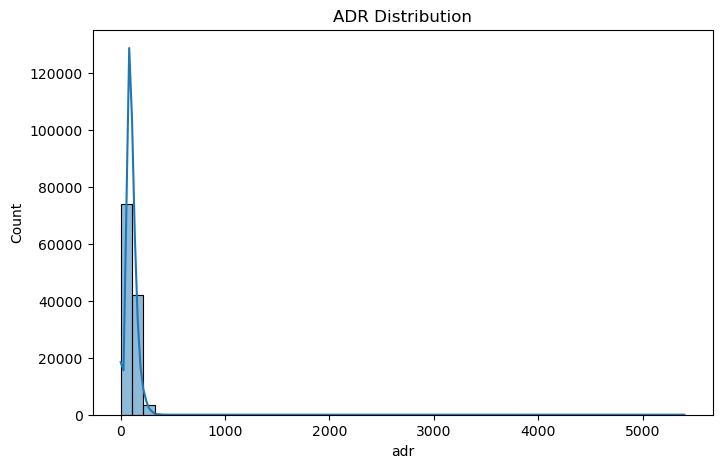

In [144]:
# Analyzing non-zero ADR values for outliers

adr_nonzero = df[df['adr'] > 0]['adr']

Q1 = adr_nonzero.quantile(0.25)
Q3 = adr_nonzero.quantile(0.75)
IQR = Q3 - Q1
nZero_lower_bound = Q1 - 1.5 * IQR
nZero_upper_bound = Q3 + 1.5 * IQR
print(f"ADR IQR bounds: {nZero_lower_bound:.2f} to {nZero_upper_bound:.2f}")

outliers = df[(df['adr'] < nZero_lower_bound) | (df['adr'] > nZero_upper_bound)]
print(f"Outliers count: {len(outliers)}")

plt.figure(figsize=(8,5))
sns.histplot(df['adr'], bins=50, kde=True)
plt.title('ADR Distribution')
plt.show()

In [145]:
round(df['adr'].skew())

11

- Capping excluded Zero ADR values 

In [146]:
df['adr'] = np.where(df['adr'] > nZero_upper_bound, nZero_upper_bound,
                     np.where(df['adr'] < nZero_lower_bound, nZero_lower_bound, df['adr']))

- Replacing suspicious zero ADR values with mdeian

In [147]:
median_adr = df['adr'].median()
df.loc[(df['adr'] == 0) & (df['adr_flag'] == 'suspicious_zero'), 'adr'] = median_adr

In [148]:
df['adr'].describe()

count    119389.000000
mean        101.982129
std          42.827426
min           0.000000
25%          71.000000
50%          94.590000
75%         126.000000
max         209.205000
Name: adr, dtype: float64

In [149]:
df.groupby('hotel')['adr'].describe()[['mean', 'min', 'max']]


,mean,min,max
hotel,,,
City Hotel,106.013871,0.0,209.205
Resort Hotel,93.997954,0.0,209.205


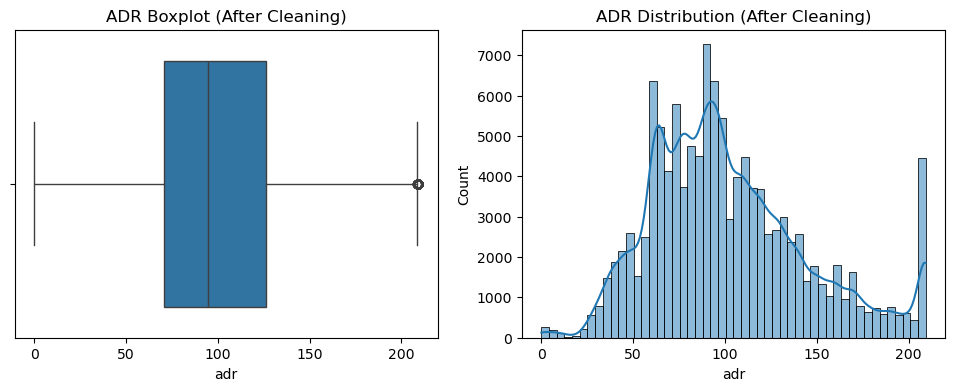

In [150]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
sns.boxplot(x=df['adr'], ax=ax[0])
sns.histplot(df['adr'], bins=50, kde=True, ax=ax[1])
ax[0].set_title('ADR Boxplot (After Cleaning)')
ax[1].set_title('ADR Distribution (After Cleaning)')
plt.show()


<h2>Adding Columns</h2>

- Adding Tourism Type Column

In [151]:
df['tourism_type']= np.where(df['country']=='PRT', 'Domestic', 'International')
df['tourism_type'].value_counts()
df['tourism_type'].shape

(119389,)

- Checking Data Types for numircal Data

In [152]:
df[['stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'adr']].dtypes

stays_in_weekend_nights      int64
stays_in_week_nights         int64
adults                       int64
children                   float64
babies                       int64
adr                        float64
dtype: object

- Adding arrival_date column

In [153]:

df['arrival_date'] = pd.to_datetime(
    df['arrival_date_year'].astype(str) + '-' +
    df['arrival_date_month'] + '-' +
    df['arrival_date_day_of_month'].astype(str),
    format='%Y-%B-%d',
    errors='coerce'  # handle invalid month names safely
)

print(df['arrival_date'].head(10))
print(f"Null arrival_date values: {df['arrival_date'].isna().sum()}")


0   2015-07-01
1   2015-07-01
2   2015-07-01
3   2015-07-01
4   2015-07-01
5   2015-07-01
6   2015-07-01
7   2015-07-01
8   2015-07-01
9   2015-07-01
Name: arrival_date, dtype: datetime64[ns]
Null arrival_date values: 0


- Adding Total Guests,Total Nights,Revenue columns

In [154]:
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['revenue'] = df['adr'] * df['total_nights']
df['revenue'].sum()

np.float64(42384656.220000006)

In [155]:
df['revenue'].describe()

count    119389.000000
mean        355.013077
std         320.253934
min           0.000000
25%         150.000000
50%         267.300000
75%         442.000000
max        7590.000000
Name: revenue, dtype: float64

In [156]:
# Bookings with 0 or negative total nights
invalid_nights = df[df['total_nights'] <= 0]
print(f"Invalid night count: {len(invalid_nights)}")

# Zero or negative revenue (excluding canceled)
invalid_revenue = df[(df['revenue'] <= 0) & (df['is_canceled'] == 0)]
print(f"Invalid revenue count: {len(invalid_revenue)}")

Invalid night count: 715
Invalid revenue count: 680


In [157]:
# Step 1: Remove impossible stays
df = df[df['total_nights'] > 0]

# Step 2: Set canceled booking revenue to 0
df.loc[df['is_canceled'] == 1, 'revenue'] = 0

# Step 3: Revalidate revenue stats
print("After cleaning:")
print(df['revenue'].describe())

# Optional: confirm no invalids remain
invalid_revenue = df[(df['revenue'] <= 0) & (df['is_canceled'] == 0)]
print(f"Remaining invalid revenue count: {len(invalid_revenue)}")


After cleaning:
count    118674.000000
mean        218.356017
std         297.271310
min           0.000000
25%           0.000000
50%         124.000000
75%         324.520000
max        7590.000000
Name: revenue, dtype: float64
Remaining invalid revenue count: 0


In [158]:
invalid_guests = df[df['total_guests'] <= 0]
print(f"Invalid guest count: {len(invalid_guests)}")

zero_adults = df[df['adults'] == 0]
print(f"Zero adults count: {len(zero_adults)}")

negative_lead = df[df['lead_time'] < 0]
print(f"Negative lead_time count: {len(negative_lead)}")

negative_lead = df[df['lead_time'] < 0]
print(f"Negative lead_time count: {len(negative_lead)}")

Invalid guest count: 0
Zero adults count: 3
Negative lead_time count: 0
Negative lead_time count: 0


In [159]:
df.sample(15)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone_number,credit_card,adr_flag,tourism_type,arrival_date,total_nights,total_guests,revenue
89653,City Hotel,0,1,2016,May,22,23,1,0,2,0.0,0,BB,FRA,Direct,Direct,0,0,0,D,...,1,No Deposit,0.0,0,Transient,172.00,1,1,Check-Out,2016-05-24,James Mason,James_M@hotmail.com,255-721-7751,************6133,valid,International,2016-05-23,1,2.0,172.00
56465,City Hotel,1,13,2016,September,37,7,0,1,2,0.0,0,SC,POL,Online TA,TA/TO,0,0,0,A,...,0,No Deposit,9.0,0,Transient,119.00,0,0,Canceled,2016-08-29,Hannah Rose,Rose_Hannah@verizon.com,609-051-9479,************6891,valid,International,2016-09-07,1,2.0,0.00
95477,City Hotel,0,320,2016,August,34,18,0,2,2,0.0,0,HB,DEU,Offline TA/TO,TA/TO,0,0,0,A,...,0,No Deposit,6.0,0,Transient-Party,115.00,0,1,Check-Out,2016-08-20,Jerry Lee,JLee@hotmail.com,738-818-4666,************6069,valid,International,2016-08-18,2,2.0,230.00
43319,City Hotel,0,72,2015,September,38,18,0,1,2,0.0,0,HB,PRT,Offline TA/TO,TA/TO,0,0,0,A,...,0,No Deposit,6.0,0,Transient-Party,108.00,0,0,Check-Out,2015-09-19,Michael Allen,Michael_A@aol.com,134-711-9564,************2010,valid,Domestic,2015-09-18,1,2.0,108.00
99851,City Hotel,0,48,2016,October,43,17,1,1,3,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,D,...,0,No Deposit,9.0,0,Transient,158.40,0,2,Check-Out,2016-10-19,Roger Montoya,RogerMontoya@mail.com,945-869-2087,************4438,valid,International,2016-10-17,2,3.0,316.80
24500,Resort Hotel,0,125,2016,May,21,17,2,5,2,0.0,0,BB,IRL,Offline TA/TO,TA/TO,0,0,0,A,...,0,No Deposit,175.0,0,Transient,41.76,0,0,Check-Out,2016-05-24,Leah Mckee,Mckee.Leah@comcast.net,875-981-8676,************6896,valid,International,2016-05-17,7,2.0,292.32
6121,Resort Hotel,0,225,2016,May,22,26,0,3,2,0.0,0,BB,GBR,Groups,Direct,0,0,0,A,...,1,No Deposit,0.0,0,Transient-Party,72.00,1,0,Check-Out,2016-05-29,Cristina Gray,Gray_Cristina@yahoo.com,240-732-7403,************6591,valid,International,2016-05-26,3,2.0,216.00
17169,Resort Hotel,0,185,2015,September,38,19,4,6,2,0.0,0,BB,GBR,Offline TA/TO,TA/TO,0,0,0,A,...,0,No Deposit,156.0,0,Contract,51.75,0,0,Check-Out,2015-09-29,James White,JWhite@outlook.com,500-467-9270,************9905,valid,International,2015-09-19,10,2.0,517.50
45949,City Hotel,1,92,2015,December,49,1,4,15,1,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,...,0,No Deposit,9.0,0,Contract,63.75,0,1,Canceled,2015-11-19,Thomas Mclaughlin PhD,Thomas.PhD23@zoho.com,561-184-4210,************7394,valid,Domestic,2015-12-01,19,1.0,0.00
53758,City Hotel,1,20,2016,June,27,29,0,3,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,E,...,0,No Deposit,14.0,0,Transient,177.00,0,0,Canceled,2016-06-15,Kristina Day,Kristina_D@yandex.com,773-022-1189,************1145,valid,International,2016-06-29,3,1.0,0.00


In [160]:
numric = df.select_dtypes(include = [np.number]).columns.tolist()
df[numric].corr()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,total_nights,total_guests,revenue
is_canceled,1.000000,0.291677,0.015515,0.008884,-0.006212,-0.005522,0.019662,0.058706,0.004802,-0.032622,-0.077613,0.110003,-0.057513,-0.144738,-0.046133,0.053806,0.030011,-0.196697,-0.236000,0.012512,0.044780,-0.565766
lead_time,0.291677,1.000000,0.039609,0.127907,0.002417,0.082124,0.161464,0.118928,-0.038162,-0.020997,-0.116016,0.085912,-0.073754,-0.000903,-0.012702,0.169955,-0.087495,-0.117497,-0.096843,0.152669,0.070310,-0.043461
arrival_date_year,0.015515,0.039609,1.000000,-0.540376,0.000345,0.020225,0.029192,0.030906,0.054985,-0.013034,0.012159,-0.120272,0.029306,0.030942,0.058125,-0.056839,0.207552,-0.014123,0.109557,0.029707,0.053168,0.040690
arrival_date_week_number,0.008884,0.127907,-0.540376,1.000000,0.066745,0.018876,0.016447,0.026853,0.005735,0.010154,-0.032967,0.035624,-0.021167,0.005463,-0.018866,0.023124,0.086108,0.002103,0.025855,0.019667,0.025833,0.049303
arrival_date_day_of_month,-0.006212,0.002417,0.000345,0.066745,1.000000,-0.016515,-0.028527,-0.000944,0.014487,-0.000222,-0.005219,-0.027105,-0.000321,0.010641,0.000119,0.022758,0.030730,0.008659,0.003358,-0.027758,0.007240,0.000805
stays_in_weekend_nights,-0.005522,0.082124,0.020225,0.018876,-0.016515,1.000000,0.495467,0.092681,0.045516,0.018519,-0.078124,-0.013312,-0.042946,0.064254,0.163034,-0.054997,0.034075,-0.019507,0.072554,0.761376,0.101164,0.390321
stays_in_week_nights,0.019662,0.161464,0.029192,0.016447,-0.028527,0.495467,1.000000,0.093152,0.043823,0.020264,-0.083339,-0.014779,-0.049125,0.097937,0.197749,-0.003014,0.045966,-0.026271,0.068009,0.940377,0.100837,0.471764
adults,0.058706,0.118928,0.030906,0.026853,-0.000944,0.092681,0.093152,1.000000,0.045114,0.017718,-0.144812,-0.007437,-0.109803,-0.045412,0.021860,-0.009173,0.231131,0.013543,0.125835,0.105817,0.820055,0.120432
children,0.004802,-0.038162,0.054985,0.005735,0.014487,0.045516,0.043823,0.045114,1.000000,0.024201,-0.031664,-0.024816,-0.021051,0.049263,0.050352,-0.033403,0.325714,0.056367,0.081990,0.050531,0.592509,0.106086
babies,-0.032622,-0.020997,-0.013034,0.010154,-0.000222,0.018519,0.020264,0.017718,0.024201,1.000000,-0.009124,-0.007518,-0.006593,0.084036,0.030345,-0.010650,0.032363,0.037192,0.097855,0.022376,0.162725,0.046686


# key Corlations insghts :
- What Predicts a Cancellation?

1- lead_time (0.29): This is a moderate positive correlation. It confirms one of our hypotheses: The longer the lead time, the more likely a booking is to be canceled

2- total_of_special_requests (-0.24): A moderate negative correlation. Guests who make special requests are less likely to cancel. They are more invested in their specific stay.

3- required_car_parking_spaces (-0.20): Another good negative correlation. Guests who need a parking space are less likely to cancel

- Drives Revenue?

total_guests (0.16): A weak positive correlation. This suggests that the number of guests isn't as strong a driver of revenue as the length of stay or the price of the room.



In [161]:
revenue_kpi=df['revenue'].sum().round()
guests_kpi=df['total_guests'].sum()
print(f"Total Revenue: ${revenue_kpi}")
print(f"Total Guests: {guests_kpi}")

Total Revenue: $25913182.0
Total Guests: 234158.0


In [162]:
df.groupby('arrival_date_year')['revenue'].sum()

arrival_date_year
2015    4.573205e+06
2016    1.166761e+07
2017    9.672364e+06
Name: revenue, dtype: float64

- Time-series booking counts to see seasonality before plotting monthly KPIs

<Axes: title={'center': 'Daily bookings'}, xlabel='arrival_date'>

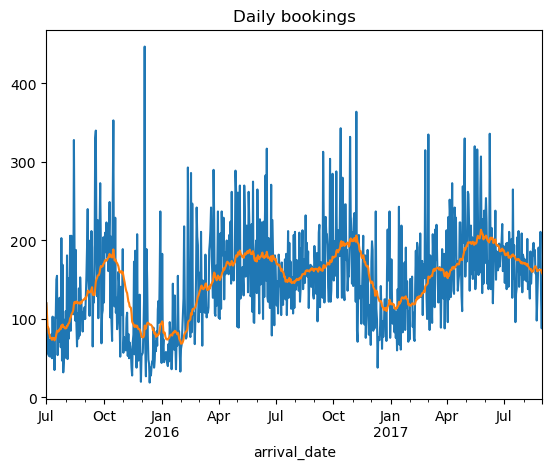

In [163]:
ts = df.groupby('arrival_date').size().rename('bookings')
ts_30 = ts.rolling(30, min_periods=1).mean()
ts.plot(title='Daily bookings'); ts_30.plot()


- VIF — to detect collinearity and decide which features to keep/drop.

In [164]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# choose numeric columns (exclude target and identifiers)
num_cols = ['lead_time','stays_in_weekend_nights','stays_in_week_nights','adults','children',
            'babies','previous_cancellations','previous_bookings_not_canceled','booking_changes',
            'days_in_waiting_list','adr','required_car_parking_spaces','total_of_special_requests',
            'total_nights','total_guests']
X = df[num_cols].dropna()
vif = pd.DataFrame()
vif['feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif.sort_values('VIF', ascending=False))


                           feature       VIF
1          stays_in_weekend_nights       inf
2             stays_in_week_nights       inf
3                           adults       inf
4                         children       inf
5                           babies       inf
13                    total_nights       inf
14                    total_guests       inf
10                             adr  6.622163
0                        lead_time  2.131943
12       total_of_special_requests  1.650309
8                  booking_changes  1.140024
11     required_car_parking_spaces  1.093358
9             days_in_waiting_list  1.056926
6           previous_cancellations  1.050120
7   previous_bookings_not_canceled  1.039827


- Categorical association tests (chi-square)

In [165]:
import scipy.stats as stats
ct = pd.crosstab(df['market_segment'], df['is_canceled'])
chi2, p, dof, ex = stats.chi2_contingency(ct)
print('chi2', chi2, 'p-value', p)


chi2 8426.52106468118 p-value 0.0


- t-test / ANOVA for ADR differences across key groups

In [166]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
model = ols('adr ~ C(hotel)', data=df).fit()
print(sm.stats.anova_lm(model, typ=2))


                sum_sq        df            F  PR(>F)
C(hotel)  3.846674e+06       1.0  2125.874772     0.0
Residual  2.147316e+08  118672.0          NaN     NaN


- Simple logistic baseline

In [167]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
X = df[['lead_time','adr','total_nights']].fillna(0)
y = df['is_canceled']
X_train,X_test,y_train,y_test = train_test_split(X,y,stratify=y,test_size=0.2,random_state=42)
clf = LogisticRegression(max_iter=1000).fit(X_train,y_train)
pred = clf.predict_proba(X_test)[:,1]
roc_auc_score(y_test,pred)


np.float64(0.6888163207376934)


--- lead_time ---
count    118674.000000
mean        104.465721
std         106.906085
min           0.000000
25%          18.000000
50%          70.000000
75%         161.000000
max         709.000000
Name: lead_time, dtype: float64
skewness: 1.341, kurtosis: 1.678


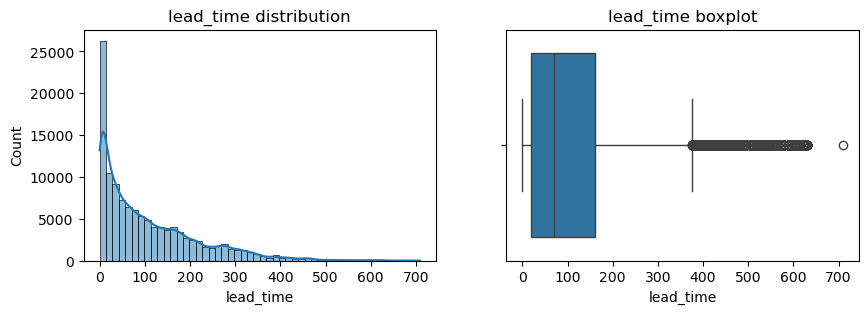


--- adr ---
count    118674.000000
mean        102.054563
std          42.916822
min           0.000000
25%          70.955000
50%          95.000000
75%         126.000000
max         209.205000
Name: adr, dtype: float64
skewness: 0.688, kurtosis: 0.099


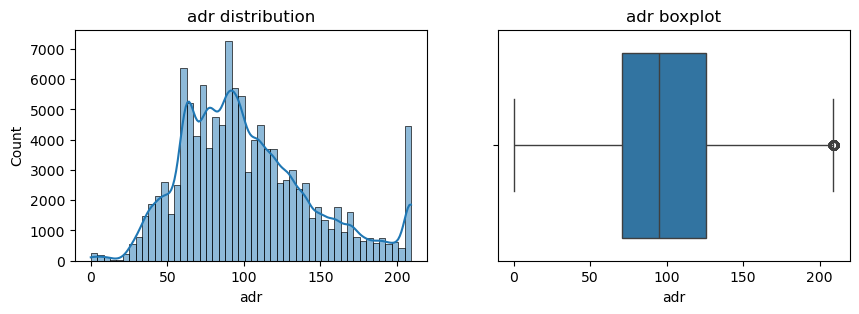


--- total_nights ---
count    118674.000000
mean          3.448498
std           2.551151
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          69.000000
Name: total_nights, dtype: float64
skewness: 3.344, kurtosis: 29.254


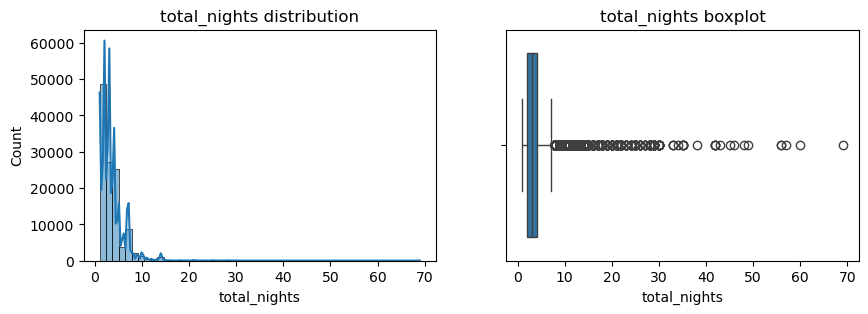


--- total_guests ---
count    118674.000000
mean          1.973120
std           0.720808
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max          55.000000
Name: total_guests, dtype: float64
skewness: 10.298, kurtosis: 562.581


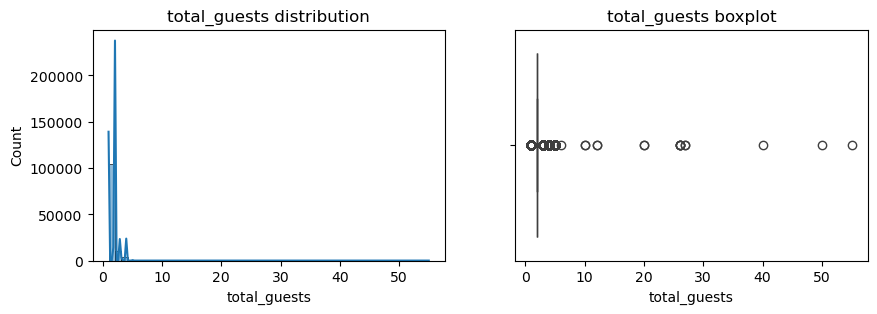


--- revenue ---
count    118674.000000
mean        218.356017
std         297.271310
min           0.000000
25%           0.000000
50%         124.000000
75%         324.520000
max        7590.000000
Name: revenue, dtype: float64
skewness: 2.728, kurtosis: 15.683


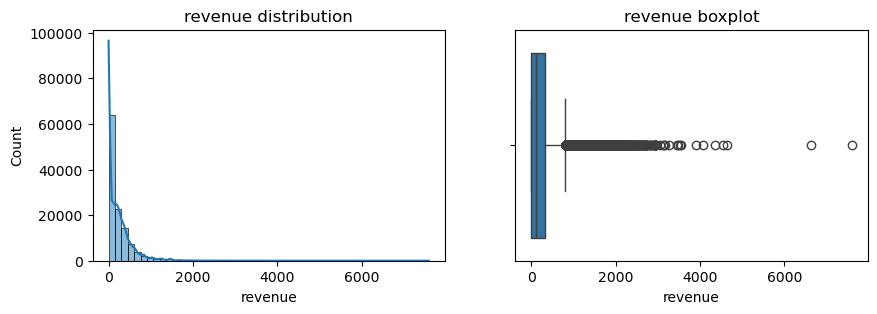

In [168]:
# EDA Task 1: Univariate numeric distributions
from scipy.stats import skew, kurtosis

num_cols = ['lead_time','adr','total_nights','total_guests','revenue']  # adjust names if needed

for col in num_cols:
    data = df[col].dropna()
    print(f"\n--- {col} ---")
    print(data.describe())
    print(f"skewness: {skew(data):.3f}, kurtosis: {kurtosis(data):.3f}")
    
    # Plot histogram + KDE
    plt.figure(figsize=(10,3))
    plt.subplot(1,2,1)
    sns.histplot(data, bins=50, kde=True)
    plt.title(f'{col} distribution')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=data)
    plt.title(f'{col} boxplot')
    plt.show()


| Feature          | Key Stats                               | Shape / Skew                         | What It Means                                                                                     | Next Action                                                                               |
| ---------------- | --------------------------------------- | ------------------------------------ | ------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------- |
| **lead_time**    | mean = 104 days, median = 70, max = 709 | right-skewed (1.34)                  | Most bookings are within 2–3 months before arrival, but a long tail exists (some > 1 year ahead). | ✅ Keep as-is for EDA; create *binned version* later (e.g. 0–30, 31–90, 91–180, >180).     |
| **adr**          | mean ≈ 102, fairly tight std ≈ 43       | mildly right-skewed (0.68)           | Rates cluster near 70–130 €/night; no major outliers (max ≈ 209).                                 | ✅ Fine for direct use; median is reliable for group comparisons.                          |
| **total_nights** | mean = 3.4, median = 3, max = 69        | heavily right-skewed (3.34, kurt 29) | Most stays are short (1–5 nights), but a few long stays inflate average.                          | ⚠️ Use log(1+x) or capped 95th % winsorization for modeling; explore stay-length buckets. |
| **total_guests** | mean ≈ 2, max = 55 (!), skew 10.3       | extremely right-skewed               | Clearly a few unrealistic outliers — possibly group/agency errors.                                | ⚠️ Trim top 1% (e.g. guests > 5) before aggregating KPIs; confirm in EDA visuals.         |
| **revenue**      | mean = 218, median = 124, max = 7590    | right-skewed (2.73, 15.7)            | Revenue driven by long stays or group bookings; long tail of high-value guests.                   | ✅ Visualize in log scale; check correlation with stay length and ADR.                     |


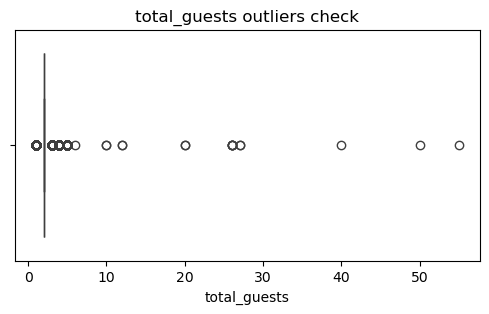

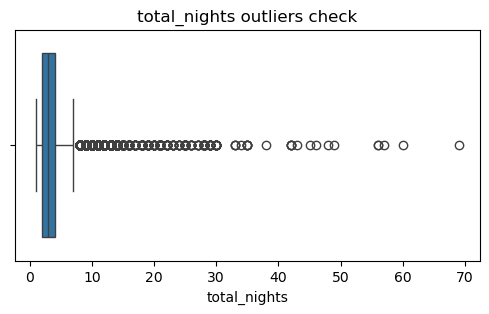

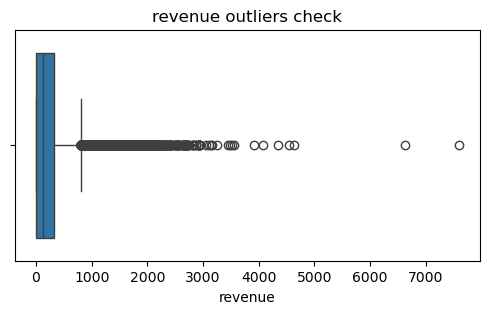

             hotel arrival_date  total_guests  total_nights  adr  revenue
2173  Resort Hotel   2015-10-04          55.0             2  0.0      0.0
1643  Resort Hotel   2015-09-07          50.0             3  0.0      0.0
1539  Resort Hotel   2015-09-03          40.0             3  0.0      0.0
1917  Resort Hotel   2015-09-21          27.0             4  0.0      0.0
1962  Resort Hotel   2015-09-24          27.0             4  0.0      0.0


In [169]:
# Quick check for possible outliers in guests and nights
outlier_cols = ['total_guests', 'total_nights', 'revenue']
for col in outlier_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'{col} outliers check')
    plt.show()

# Top 5 largest guest groups
print(df.nlargest(5, 'total_guests')[['hotel', 'arrival_date', 'total_guests', 'total_nights', 'adr', 'revenue']])


| Field          | Observation                       | Why It’s Wrong                                                                                                        |
| -------------- | --------------------------------- | --------------------------------------------------------------------------------------------------------------------- |
| `total_guests` | Ranges from 27 to 55              | Unrealistically high for a single booking in a hotel dataset (SmartStay doesn’t seem to have “group” booking fields). |
| `adr`          | `0.0`                             | No daily rate recorded — not consistent with active stays.                                                            |
| `revenue`      | `0.0`                             | Confirms these weren’t billed stays → very likely placeholder / system test entries.                                  |
| `hotel`        | All “Resort Hotel”                | Possibly a batch upload or data-entry test for one property.                                                          |
| `total_nights` | Reasonable (2–4), but revenue = 0 | Confirms invalid records.                                                                                             |


In [170]:
invalid_guests = df[(df['total_guests'] > 10) & (df['adr'] == 0) & (df['revenue'] == 0)]
print(f"Invalid records to drop: {len(invalid_guests)}")

Invalid records to drop: 12


In [171]:
df = df.drop(invalid_guests.index).reset_index(drop=True)
print(f"Remaining records after cleaning: {len(df)}")

Remaining records after cleaning: 118662


In [172]:
print(df['total_guests'].describe())

count    118662.000000
mean          1.970210
std           0.651097
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max          12.000000
Name: total_guests, dtype: float64


In [173]:
# Cleaned dataset for Tableau
clean_tableau = df.copy()

# Drop duplicates and ensure consistent data types
clean_tableau = clean_tableau.drop_duplicates()
clean_tableau['lead_time_bin'] = pd.cut(clean_tableau['lead_time'], bins=[0,30,90,180,365,710],
                                        labels=['0-30','31-90','91-180','181-365','366-710'])
clean_tableau['is_canceled'] = clean_tableau['is_canceled'].astype(int)


# Save to CSV for Tableau
clean_tableau.to_csv("smart_stay_cleaned.csv", index=False)
print("✅ Clean dataset exported: 'smart_stay_cleaned.csv'")

✅ Clean dataset exported: 'smart_stay_cleaned.csv'


# Modeling

In [174]:
### DIM TABLES ###

# Guests info dimension
dim_guests_info = df[['name', 'email', 'country', 'phone_number',
                            'credit_card', 'is_repeated_guest',
                            'previous_cancellations',
                            'previous_bookings_not_canceled']].drop_duplicates().reset_index(drop=True)
dim_guests_info['guests_info_id'] = dim_guests_info.index + 1
print('✅ dim_guests_info created')

# Customer type dimension
dim_customer_type = df[['customer_type', 'tourism_type']].drop_duplicates().reset_index(drop=True)
dim_customer_type['customer_type_id'] = dim_customer_type.index + 1
print('✅ dim_customer_type created')


# Guests types (adults, children, babies) dimention
dim_guests_types = df[['adults', 'children', 'babies', 'total_guests']].drop_duplicates().reset_index(drop=True)
dim_guests_types['guest_type_id'] = dim_guests_types.index + 1
print('✅ dim_guests_types created')

# Deposit type dimention
dim_deposit_type = df[['deposit_type']].drop_duplicates().reset_index(drop=True)
dim_deposit_type['deposit_type_id'] = dim_deposit_type.index + 1
print('✅ dim_deposit_type created')

# Booking type (hotel) dimention
dim_booking_type = df[['hotel']].drop_duplicates().reset_index(drop=True)
dim_booking_type['hotel_id'] = dim_booking_type.index + 1
print('✅ dim_booking_type created')

# Arrival date dimension
dim_arrival_date = df[['arrival_date', 'arrival_date_day_of_month',
                             'arrival_date_month', 'arrival_date_year']].drop_duplicates().reset_index(drop=True)
dim_arrival_date['arrival_date_id'] = dim_arrival_date.index + 1
print('✅ dim_arrival_date created')

# Reservation status Date dimension
dim_reservation_status_date = df[['reservation_status_date']].drop_duplicates().reset_index(drop=True)
dim_reservation_status_date['reservation_status_date_id'] = dim_reservation_status_date.index + 1
print('✅ dim_reservation_status_date created') 

# Stayed nights dimension
dim_stayed_nights = df[['stays_in_weekend_nights', 'stays_in_week_nights', 'total_nights']].drop_duplicates().reset_index(drop=True)
dim_stayed_nights['nights_stayed_id'] = dim_stayed_nights.index + 1
print('✅ dim_stayed_nights created')

# Reservation details dimension
dim_reservation_details = df[['assigned_room_type', 'reserved_room_type', 'meal',
                                    'required_car_parking_spaces']].drop_duplicates().reset_index(drop=True)
dim_reservation_details['reservation_details_id'] = dim_reservation_details.index + 1
print('✅ dim_reservation_details created')

# Marketing (agent, market_segment, distribution_channel) dimention
dim_marketing = df[['agent', 'market_segment', 'distribution_channel']].drop_duplicates().reset_index(drop=True)
dim_marketing['market_key'] = dim_marketing.index + 1
print('✅ dim_marketing created')

# Reservation status
dim_reservation_status = df[['reservation_status']].drop_duplicates().reset_index(drop=True)
dim_reservation_status['reservation_status_id'] = dim_reservation_status.index + 1
print('✅ dim_reservation_status created')

### FACT TABLE ###
fact_bookings = df.copy()

# Merge IDs from dimensions
fact_bookings = fact_bookings.merge(dim_guests_info, on=['name', 'email', 'country', 'phone_number',
                                                         'credit_card', 'is_repeated_guest',
                                                         'previous_cancellations',
                                                         'previous_bookings_not_canceled'], how='left')

fact_bookings = fact_bookings.merge(dim_customer_type, on=['customer_type', 'tourism_type'], how='left')
fact_bookings = fact_bookings.merge(dim_guests_types, on=['adults', 'children', 'babies', 'total_guests'], how='left')
fact_bookings = fact_bookings.merge(dim_booking_type, on='hotel', how='left')
fact_bookings = fact_bookings.merge(dim_arrival_date, on=['arrival_date', 'arrival_date_day_of_month',
                                                          'arrival_date_month', 'arrival_date_year'], how='left')
fact_bookings = fact_bookings.merge(dim_stayed_nights, on=['stays_in_weekend_nights', 'stays_in_week_nights', 'total_nights'], how='left')
fact_bookings = fact_bookings.merge(dim_reservation_details, on=['assigned_room_type', 'reserved_room_type', 'meal',
                                                                 'required_car_parking_spaces'], how='left')
fact_bookings = fact_bookings.merge(dim_marketing, on=['agent', 'market_segment', 'distribution_channel'], how='left')
fact_bookings = fact_bookings.merge(dim_reservation_status, on='reservation_status', how='left')
fact_bookings = fact_bookings.merge(dim_deposit_type, on='deposit_type', how='left')

fact_bookings = fact_bookings[['lead_time', 'days_in_waiting_list', 'adr', 'revenue',
                               'total_of_special_requests', 'booking_changes',
                               'is_canceled', 'customer_type_id', 'guest_type_id', 'hotel_id',
                               'arrival_date_id', 'nights_stayed_id', 'reservation_details_id',
                               'market_key', 'guests_info_id', 'reservation_status_id', 'deposit_type_id']]
fact_bookings['primary_key'] = range(1, len(fact_bookings) + 1)
print("✅ Fact and dimension tables created successfully.")

✅ dim_guests_info created
✅ dim_customer_type created
✅ dim_guests_types created
✅ dim_deposit_type created
✅ dim_booking_type created
✅ dim_arrival_date created
✅ dim_reservation_status_date created
✅ dim_stayed_nights created
✅ dim_reservation_details created
✅ dim_marketing created
✅ dim_reservation_status created
✅ Fact and dimension tables created successfully.


# Saving a Copy of the Tables

In [175]:
# --- Save Dimension Tables ---
dim_guests_info.to_csv('dim_guests_info.csv', index=False)
dim_customer_type.to_csv('dim_customer_type.csv', index=False)
dim_guests_types.to_csv('dim_guests_types.csv', index=False)
dim_deposit_type.to_csv('dim_deposit_type.csv', index=False)
dim_booking_type.to_csv('dim_booking_type.csv', index=False)
dim_arrival_date.to_csv('dim_arrival_date.csv', index=False)
dim_reservation_status_date.to_csv('dim_reservation_status_date.csv', index=False)
dim_stayed_nights.to_csv('dim_stayed_nights.csv', index=False)
dim_reservation_details.to_csv('dim_reservation_details.csv', index=False)
dim_marketing.to_csv('dim_marketing.csv', index=False)
dim_reservation_status.to_csv('dim_reservation_status.csv', index=False)

# --- Save Fact Table ---
# (I'm assuming your fact table DataFrame is named 'fact_bookings' based on the SQL file)
fact_bookings.to_csv('fact_bookings.csv', index=False)

print("All 11 dimension tables and 1 fact table have been saved to CSV files.")

All 11 dimension tables and 1 fact table have been saved to CSV files.


<h2>DF EDA</h2>

- Hotel-Type Distribution

hotel
City Hotel      66.574809
Resort Hotel    33.425191
Name: proportion, dtype: float64


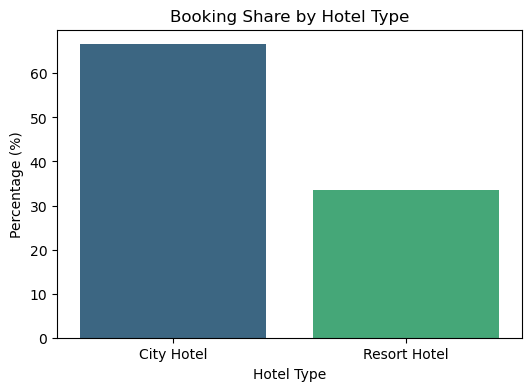

In [176]:
# Count bookings per hotel
hotel_counts = df['hotel'].value_counts(normalize=True) * 100
print(hotel_counts)

# Plot
plt.figure(figsize=(6,4))
sns.barplot(x=hotel_counts.index, y=hotel_counts.values, palette='viridis')
plt.title("Booking Share by Hotel Type")
plt.ylabel("Percentage (%)")
plt.xlabel("Hotel Type")
plt.show()


- Yearly Booking Trend

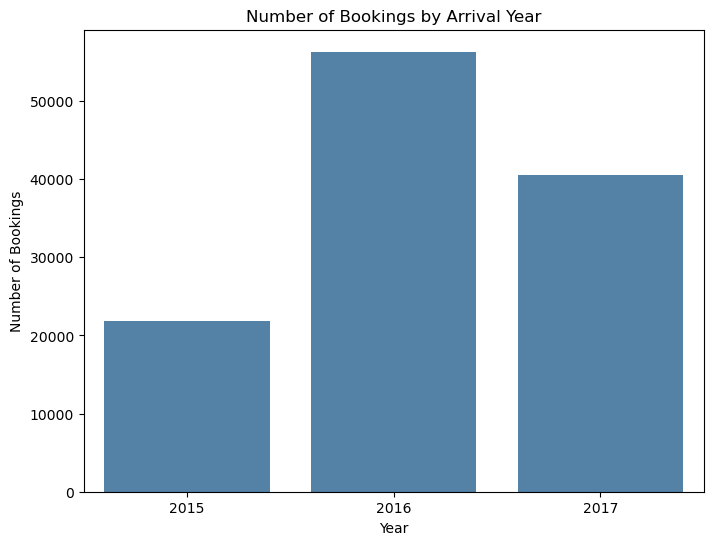

In [177]:
yearly = df['arrival_date_year'].value_counts().sort_index()

plt.figure(figsize=(8,6))
sns.barplot(x=yearly.index, y=yearly.values, color='steelblue')
plt.title("Number of Bookings by Arrival Year")
plt.ylabel("Number of Bookings")
plt.xlabel("Year")
plt.show()


- Monthly Seasonality

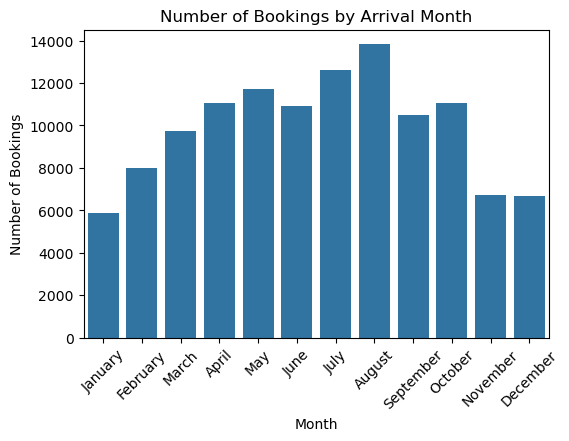

In [178]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df,x='arrival_date_month', order=['January', 'February', 'March', 'April', 'May', 'June',
                                                     'July', 'August', 'September', 'October', 'November', 'December'])
plt.title('Number of Bookings by Arrival Month')
plt.xlabel('Month')
plt.ylabel('Number of Bookings')
plt.xticks(rotation=45)
plt.show()

- Cancellation Ratio by Hotel Type

is_canceled  hotel       
0            City Hotel      38.698151
             Resort Hotel    24.072576
1            City Hotel      27.876658
             Resort Hotel     9.352615
dtype: float64


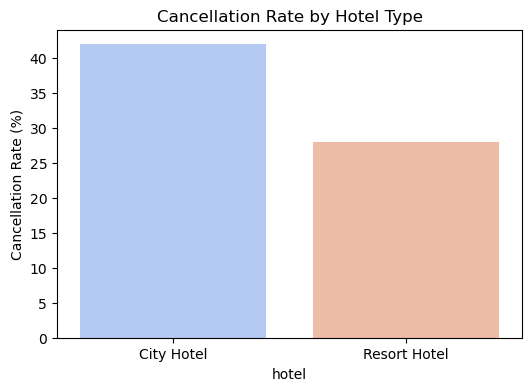

In [179]:
cancel_rate = df.groupby(['is_canceled', 'hotel']).size() / len(df) * 100
print(cancel_rate)

# Visualize cancellation ratio by hotel
cancel_ratio = df.groupby('hotel')['is_canceled'].mean() * 100

plt.figure(figsize=(6,4))
sns.barplot(x=cancel_ratio.index, y=cancel_ratio.values, palette='coolwarm')
plt.title("Cancellation Rate by Hotel Type")
plt.ylabel("Cancellation Rate (%)")
plt.show()


In [180]:
adr_summary = df.groupby('hotel')['adr'].describe()
revenue_summary = df.groupby('hotel')['revenue'].describe()

print("ADR Summary by Hotel Type:\n", adr_summary)
print("\nRevenue Summary by Hotel Type:\n", revenue_summary)


ADR Summary by Hotel Type:
                 count        mean        std  min   25%    50%    75%      max
hotel                                                                         
City Hotel    78999.0  106.089276  35.570979  0.0  80.0  100.0  126.0  209.205
Resort Hotel  39663.0   94.049279  53.769645  0.0  52.2   77.4  126.0  209.205

Revenue Summary by Hotel Type:
                 count        mean         std  min  25%    50%    75%      max
hotel                                                                         
City Hotel    78999.0  183.424842  228.254532  0.0  0.0  118.0  299.2  4634.91
Resort Hotel  39663.0  287.996441  391.594899  0.0  0.0  136.0  410.5  7590.00


In [181]:
corr = df[['adr', 'revenue', 'total_nights']].corr()
print(corr)


                   adr   revenue  total_nights
adr           1.000000  0.323171      0.047853
revenue       0.323171  1.000000      0.505049
total_nights  0.047853  0.505049      1.000000


   arrival_date_month         adr      revenue
0             January   72.035459   792667.815
1            February   74.938505  1162128.600
2               March   81.335329  1677325.770
3               April  101.082947  2109814.800
4                 May  109.488925  2402892.450
5                June  117.037573  2580887.320
6                July  125.551959  4046674.505
7              August  135.750469  4743619.285
8           September  105.988950  2365598.620
9             October   89.416653  1883017.610
10           November   75.536905  1048940.815
11           December   82.884501  1099614.330


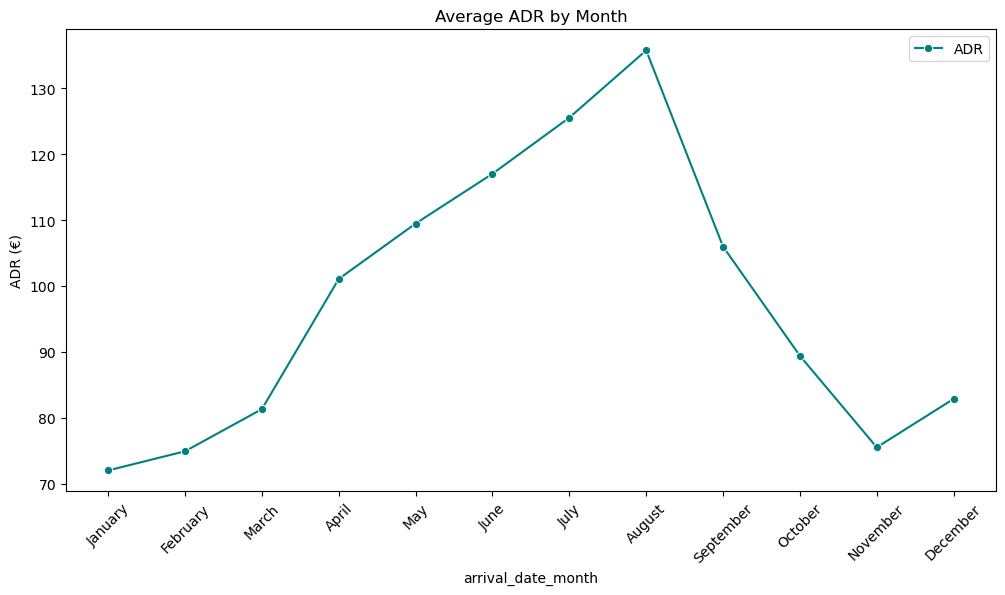

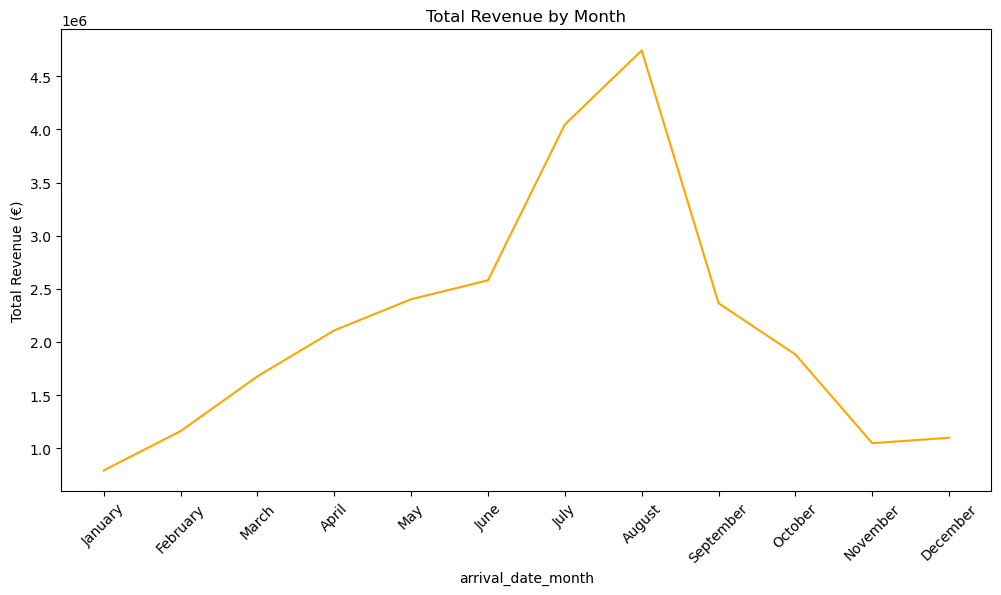

In [182]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_stats = (
    df.groupby('arrival_date_month')
      .agg({'adr':'mean', 'revenue':'sum'})
      .reindex(month_order)
      .reset_index()
)

print(monthly_stats)

# Plot ADR
plt.figure(figsize=(12,6))
sns.lineplot(x='arrival_date_month', y='adr', data=monthly_stats, marker='o', color='teal', label='ADR')
plt.title("Average ADR by Month")
plt.xticks(rotation=45)
plt.ylabel("ADR (€)")
plt.legend()
plt.show()

# Plot Total Revenue
plt.figure(figsize=(12,6))
sns.lineplot(x='arrival_date_month', y='revenue', data=monthly_stats, color='orange')
plt.title("Total Revenue by Month")
plt.xticks(rotation=45)
plt.ylabel("Total Revenue (€)")
plt.show()




 # i
 - Raise prices or bundle premium packages during July–August (demand surge).

    Introduce discounted or loyalty-based offers between November–February to reduce vacancy.

                       adr     revenue  is_canceled
market_segment                                     
Direct          114.346400  320.564424     0.154297
Aviation        102.743203  306.789437     0.220779
Online TA       116.225045  241.347798     0.368984
Offline TA/TO    88.127021  236.208468     0.345024
Complementary    78.387819  130.833444     0.122222
Corporate        70.431977  113.191178     0.188859
Groups           80.315579   97.092904     0.611712
Undefined        15.000000    0.000000     1.000000


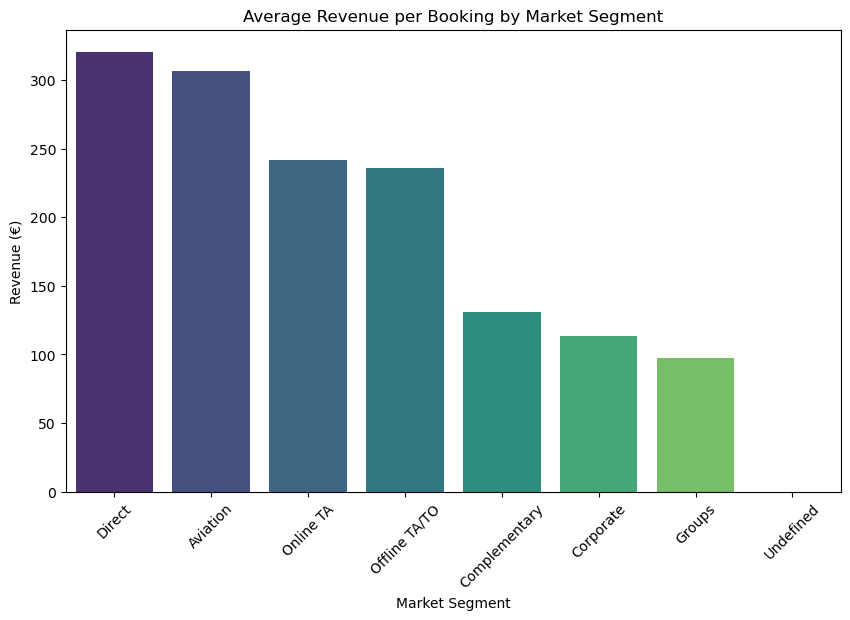

In [183]:
segment_stats = (
    df.groupby('market_segment')
      .agg({'adr':'mean', 'revenue':'mean', 'is_canceled':'mean'})
      .sort_values('revenue', ascending=False)
)

print(segment_stats)

# Visualization
plt.figure(figsize=(10,6))
sns.barplot(x=segment_stats.index, y=segment_stats['revenue'], palette='viridis')
plt.title("Average Revenue per Booking by Market Segment")
plt.ylabel("Revenue (€)")
plt.xlabel("Market Segment")
plt.xticks(rotation=45)
plt.show()



# i

- Invest in direct sales & aviation partnerships — high revenue + low cancellation risk.

- Monitor Online TA for dependency and profit margins (they might drive volume but not profit).

- Reevaluate group policies — consider deposits or flexible rebooking instead of full cancellations.

                             adr     revenue
distribution_channel                        
Direct                108.700072  296.821030
TA/TO                 103.112328  212.841029
GDS                   122.863053  174.223947
Corporate              71.488805  129.409637
Undefined              46.240000  112.700000


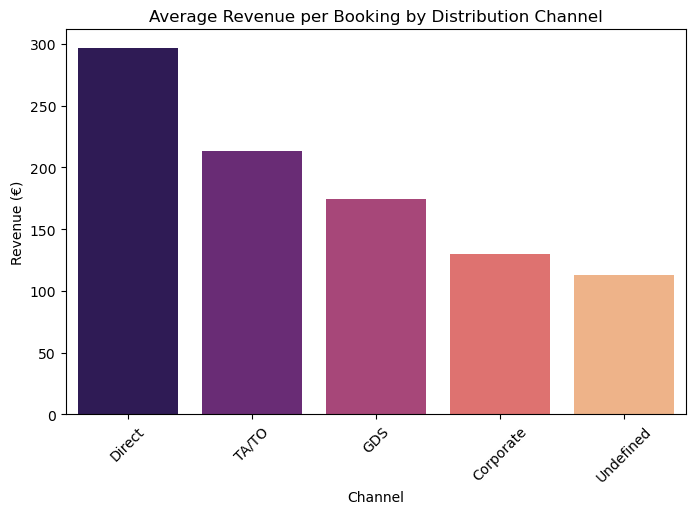

In [184]:
channel_stats = (
    df.groupby('distribution_channel')
      .agg({'adr':'mean', 'revenue':'mean'})
      .sort_values('revenue', ascending=False)
)

print(channel_stats)

plt.figure(figsize=(8,5))
sns.barplot(x=channel_stats.index, y=channel_stats['revenue'], palette='magma')
plt.title("Average Revenue per Booking by Distribution Channel")
plt.ylabel("Revenue (€)")
plt.xlabel("Channel")
plt.xticks(rotation=45)
plt.show()


# i
- Continue optimizing Direct channel marketing and website UX (highest ROI).

- For TA/TO, focus on volume but control costs through contract negotiation.

- Corporate deals may provide stability but not profitability — useful during low seasons.

   is_canceled         adr
0            0  101.062529
1            1  103.754913


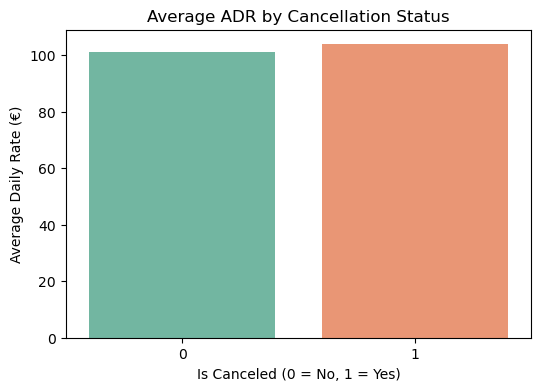

In [185]:
# ADR vs Cancellation Rate
adr_cancel = df.groupby('is_canceled')['adr'].mean().reset_index()
print(adr_cancel)
plt.figure(figsize=(6,4))
sns.barplot(data=adr_cancel, x='is_canceled', y='adr', palette='Set2')
plt.title("Average ADR by Cancellation Status")
plt.xlabel("Is Canceled (0 = No, 1 = Yes)")
plt.ylabel("Average Daily Rate (€)")
plt.show()


- Maintain transparent pricing and flexible refund policies for higher-priced bookings, especially via online channels.

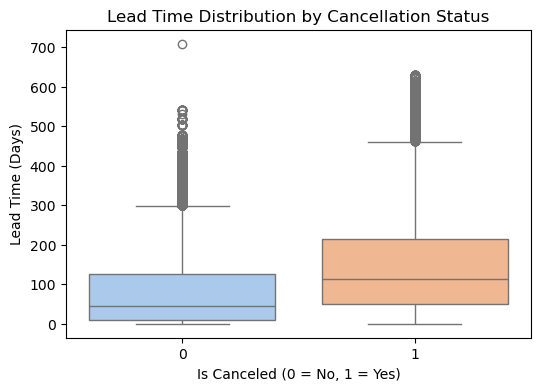

In [186]:
# Lead Time vs Cancellation
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='is_canceled', y='lead_time', palette='pastel')
plt.title("Lead Time Distribution by Cancellation Status")
plt.xlabel("Is Canceled (0 = No, 1 = Yes)")
plt.ylabel("Lead Time (Days)")
plt.show()


   is_canceled  total_of_special_requests
0            0                   0.715983
1            1                   0.328859


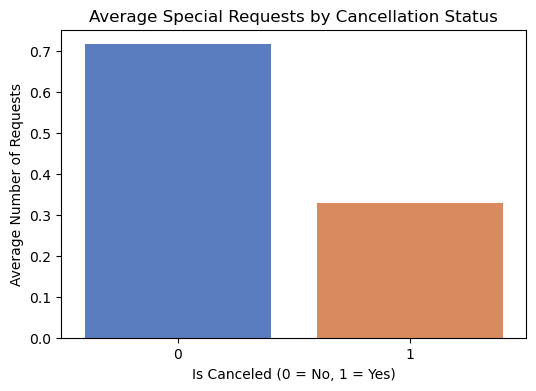

In [187]:
# Special Requests vs Cancellation
req_cancel = df.groupby('is_canceled')['total_of_special_requests'].mean().reset_index()
print(req_cancel)

plt.figure(figsize=(6,4))
sns.barplot(data=req_cancel, x='is_canceled', y='total_of_special_requests', palette='muted')
plt.title("Average Special Requests by Cancellation Status")
plt.xlabel("Is Canceled (0 = No, 1 = Yes)")
plt.ylabel("Average Number of Requests")
plt.show()


Encourage guests to personalize their bookings (e.g., room preferences, amenities) — this reduces cancellation probability and enhances satisfaction.

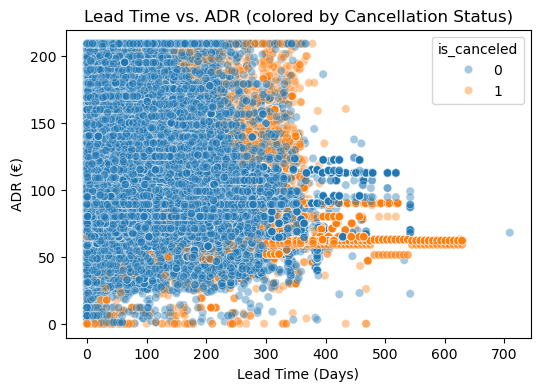

In [188]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='lead_time', y='adr', hue='is_canceled', alpha=0.4)
plt.title("Lead Time vs. ADR (colored by Cancellation Status)")
plt.xlabel("Lead Time (Days)")
plt.ylabel("ADR (€)")
plt.show()


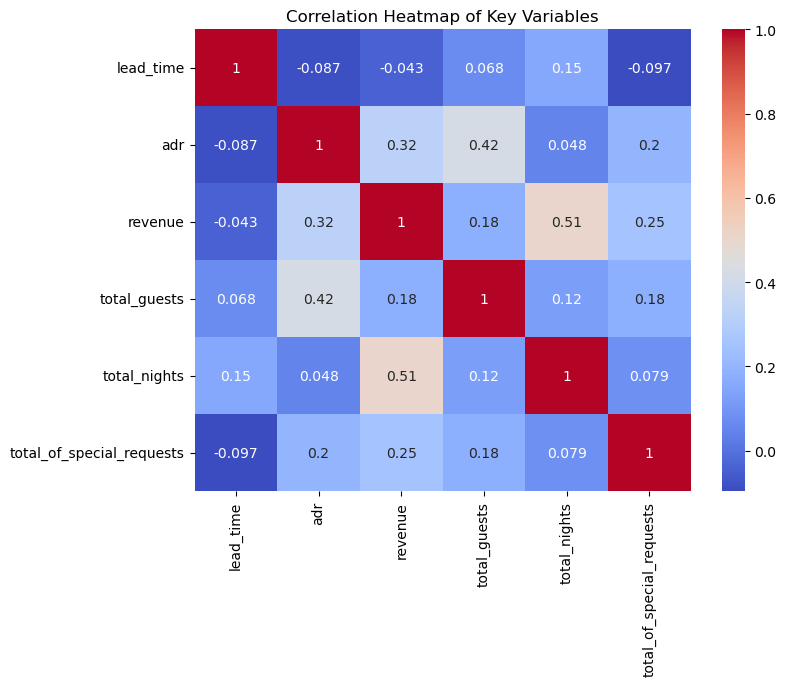

In [189]:

plt.figure(figsize=(8,6))
sns.heatmap(df[['lead_time', 'adr', 'revenue', 'total_guests', 'total_nights',
                'total_of_special_requests']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Key Variables")
plt.show()


In [190]:
df[['lead_time', 'adr', 'revenue', 'total_guests', 'total_nights',
                'total_of_special_requests']].corr()

,lead_time,adr,revenue,total_guests,total_nights,total_of_special_requests
lead_time,1.000000,-0.087012,-0.043309,0.068087,0.152540,-0.096709
adr,-0.087012,1.000000,0.323171,0.418022,0.047853,0.195213
revenue,-0.043309,0.323171,1.000000,0.180977,0.505049,0.251817
total_guests,0.068087,0.418022,0.180977,1.000000,0.124819,0.178557
total_nights,0.152540,0.047853,0.505049,0.124819,1.000000,0.079233
total_of_special_requests,-0.096709,0.195213,0.251817,0.178557,0.079233,1.000000


- Revenue is best explained by a combination of ADR, stay length, and guest count rather than price alone.
- Use predictive models or business rules to identify and re-confirm long-lead high-ADR bookings before the stay date.

| Behavior          | Finding                                     | Business Implication                            |
| ----------------- | ------------------------------------------- | ----------------------------------------------- |
| Price sensitivity | Higher ADR slightly increases cancellations | Manage dynamic pricing for high-end offers      |
| Engagement level  | Special requests reduce cancellations       | Promote request options in online booking forms |
| Revenue drivers   | Length of stay & ADR                        | Focus on multi-night bookings                   |
| Booking timing    | Longer lead time ↔ higher risk              | Reconfirm early bookings proactively            |


,adr,revenue,is_canceled,total_nights,total_guests,proportion
customer_type,,,,,,
Contract,88.01,366.55,0.31,5.34,2.00,0.034206
Group,86.89,227.82,0.08,2.86,1.83,0.004711
Transient,106.99,215.38,0.41,3.47,2.03,0.750088
Transient-Party,87.18,204.81,0.26,3.07,1.77,0.210994


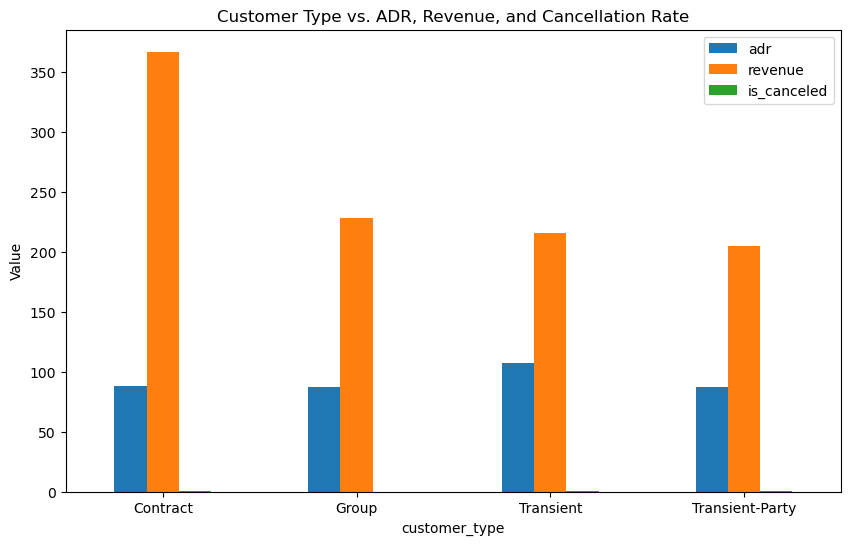

In [191]:
# Group by customer_type to analyze spending and cancellation behavior
customer_summary = df.groupby('customer_type').agg({
    'adr': 'mean',
    'revenue': 'mean',
    'is_canceled': 'mean',
    'total_nights': 'mean',
    'total_guests': 'mean'
}).round(2)

# Calculate proportions if needed
customer_summary['proportion'] = df['customer_type'].value_counts(normalize=True)

display(customer_summary)

# Optional: visualize
customer_summary[['adr', 'revenue', 'is_canceled']].plot(kind='bar', figsize=(10,6))
plt.title('Customer Type vs. ADR, Revenue, and Cancellation Rate')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.show()


| Insight                                             | Explanation                                                                                               |
| --------------------------------------------------- | --------------------------------------------------------------------------------------------------------- |
| **Transient guests dominate (75%)**                 | Most bookings come from *individual guests*, not groups or contracts — typical of online travel behavior. |
| **Highest ADR (≈ 107) for Transient**               | Individual travelers are willing to pay more, possibly due to shorter stays and higher flexibility.       |
| **Highest revenue for Contract guests (≈ 367)**     | Despite their lower ADR, they stay longer (avg. 5.3 nights), leading to higher total revenue.             |
| **Group bookings (0.47%) are minimal**              | They have short stays and the lowest ADR — likely due to negotiated rates.                                |
| **Cancellation rate highest among Transient (41%)** | This segment tends to book early via online channels, then cancel when plans change.                      |


,adr,revenue,is_canceled,proportion
deposit_type,,,,
No Deposit,103.86,248.93,0.29,0.875706
Non Refund,89.55,1.17,0.99,0.122929
Refundable,75.96,178.93,0.22,0.001365


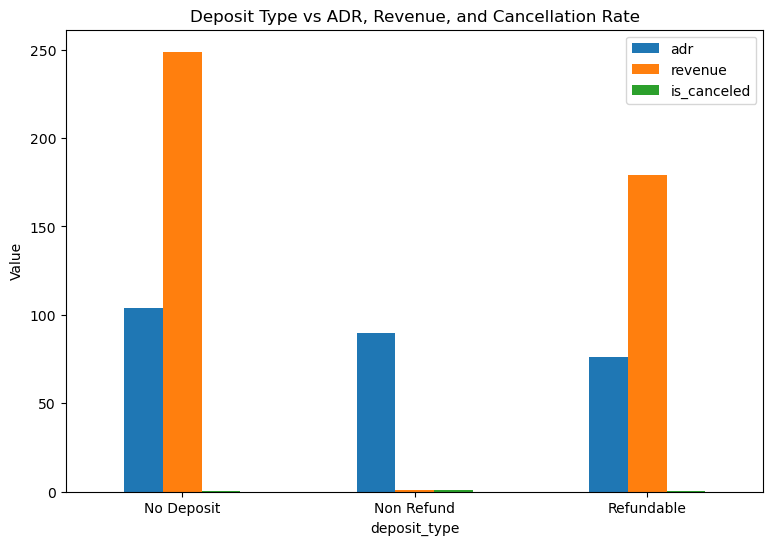

In [192]:
deposit_summary = df.groupby('deposit_type').agg({
    'adr': 'mean',
    'revenue': 'mean',
    'is_canceled': 'mean'
}).round(2)

deposit_summary['proportion'] = df['deposit_type'].value_counts(normalize=True)
display(deposit_summary)

# Visualization
deposit_summary[['adr', 'revenue', 'is_canceled']].plot(kind='bar', figsize=(9,6))
plt.title('Deposit Type vs ADR, Revenue, and Cancellation Rate')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.show()


,adr,revenue,is_canceled,proportion
meal,,,,
BB,99.94,203.53,0.38,0.773205
FB,105.47,270.66,0.60,0.006717
HB,117.69,340.26,0.35,0.121218
SC,100.04,165.60,0.37,0.089085
Undefined,92.22,326.04,0.25,0.009776


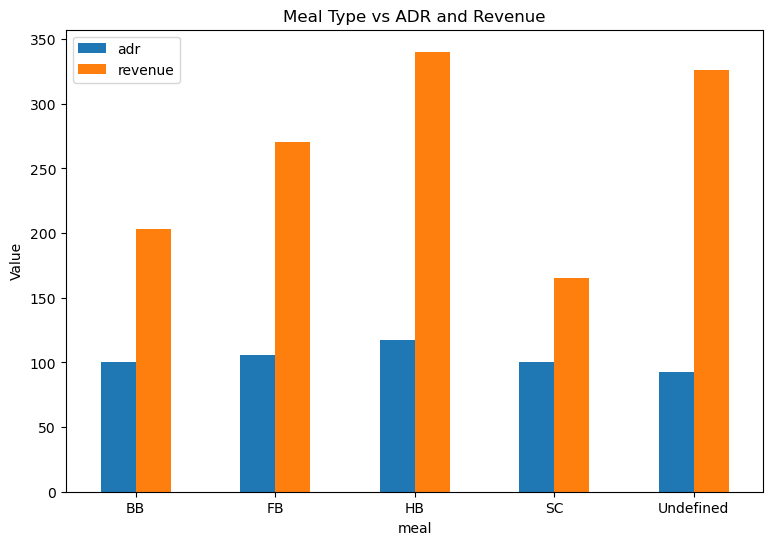

In [193]:
meal_summary = df.groupby('meal').agg({
    'adr': 'mean',
    'revenue': 'mean',
    'is_canceled': 'mean'
}).round(2)

meal_summary['proportion'] = df['meal'].value_counts(normalize=True)
display(meal_summary)

# Visualization
meal_summary[['adr', 'revenue']].plot(kind='bar', figsize=(9,6))
plt.title('Meal Type vs ADR and Revenue')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.show()


,adr,revenue,is_canceled,lead_time,proportion
market_segment,,,,,
Aviation,102.74,306.79,0.22,4.54,0.001947
Complementary,78.39,130.83,0.12,13.70,0.006068
Corporate,70.43,113.19,0.19,22.24,0.044176
Direct,114.35,320.56,0.15,50.02,0.105029
Groups,80.32,97.09,0.61,187.13,0.166641
Offline TA/TO,88.13,236.21,0.35,135.59,0.202803
Online TA,116.23,241.35,0.37,83.31,0.473319
Undefined,15.00,0.00,1.00,1.50,0.000017


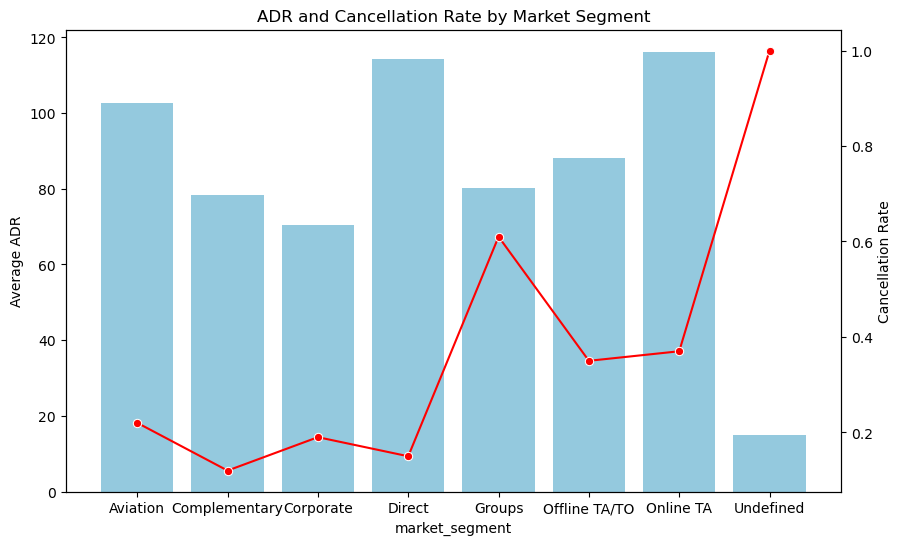

In [194]:
# Group and aggregate key metrics by market segment
market_segment_summary = df.groupby('market_segment').agg({
    'adr': 'mean',
    'revenue': 'mean',
    'is_canceled': 'mean',
    'lead_time': 'mean'
}).round(2)

# Add proportion of bookings
market_segment_summary['proportion'] = df['market_segment'].value_counts(normalize=True)
display(market_segment_summary)

# Visualize ADR vs Cancellation Rate
fig, ax1 = plt.subplots(figsize=(10,6))
sns.barplot(data=market_segment_summary.reset_index(), x='market_segment', y='adr', color='skyblue', ax=ax1)
ax2 = ax1.twinx()
sns.lineplot(data=market_segment_summary.reset_index(), x='market_segment', y='is_canceled', color='red', marker='o', ax=ax2)
ax1.set_title('ADR and Cancellation Rate by Market Segment')
ax1.set_ylabel('Average ADR')
ax2.set_ylabel('Cancellation Rate')
plt.xticks(rotation=30)
plt.show()


| Segment                 | Key Insight                                                                                           |
| ----------------------- | ----------------------------------------------------------------------------------------------------- |
| **Online TA (47%)**     | Largest source of bookings and strong ADR (≈116). But **high cancellation rate (37%)** — riskier.     |
| **Offline TA/TO (20%)** | Moderate ADR (88), fewer cancellations (35%) but very **long lead times (136 days)** — less flexible. |
| **Direct (10%)**        | **High ADR (114)** and **low cancellations (15%)** → **most profitable & stable** segment.            |
| **Groups (17%)**        | Low revenue per booking (≈97) and **very high cancellations (61%)** → needs control or special terms. |
| **Corporate (4%)**      | Lower ADR and short lead time → steady business, good for off-season occupancy.                       |
- Focus on Direct and Corporate channels to increase profit stability, and optimize Online TA by tightening cancellation policies or dynamic pricing.

,adr,revenue,is_canceled,lead_time,proportion
distribution_channel,,,,,
Corporate,71.49,129.41,0.22,45.06,0.055595
Direct,108.70,296.82,0.18,58.09,0.121951
GDS,122.86,174.22,0.19,21.01,0.001601
TA/TO,103.11,212.84,0.41,115.52,0.820810
Undefined,46.24,112.70,0.80,23.00,0.000042


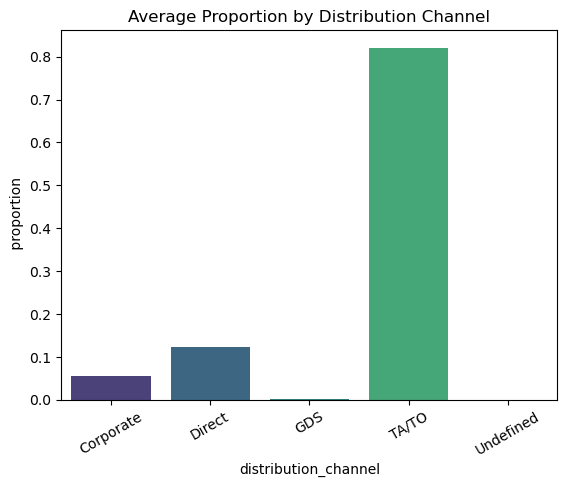

In [195]:
# Group and aggregate by distribution channel
channel_summary = df.groupby('distribution_channel').agg({
    'adr': 'mean',
    'revenue': 'mean',
    'is_canceled': 'mean',
    'lead_time': 'mean'
}).round(2)

channel_summary['proportion'] = df['distribution_channel'].value_counts(normalize=True)
display(channel_summary)

# Visualization
sns.barplot(data=channel_summary.reset_index(), x='distribution_channel', y='proportion', palette='viridis')
plt.title('Average Proportion by Distribution Channel')
plt.ylabel(' proportion')
plt.xticks(rotation=30)
plt.show()


| Channel            | Key Insight                                                                                 |
| ------------------ | ------------------------------------------------------------------------------------------- |
| **TA/TO (82%)**    | Main driver of volume but **highest cancellation rate (41%)** → high operational risk.      |
| **Direct (12%)**   | High ADR and lowest cancellations → **high-margin channel** worth investing in.             |
| **Corporate (6%)** | Reliable with moderate lead time and low cancellation → suitable for business travel deals. |
| **GDS (0.2%)**     | High ADR but very small volume → potentially niche or underutilized.                        |
- Invest in Direct channel marketing (website + loyalty offers) to reduce dependence on TA/TO, which controls most of your bookings but reduces flexibility.

In [196]:
# Top 10 countries by revenue
country_summary = (
    df.groupby('country')
      .agg({'adr':'mean',
            'revenue':'sum',
            'is_canceled':'mean',
            'lead_time':'mean'})
      .round(2)
      .sort_values(by='revenue', ascending=False)
      .head(10)
)

country_summary['proportion'] = (
    df['country'].value_counts(normalize=True).head(10).values
)

print(country_summary)


            adr     revenue  is_canceled  lead_time  proportion
country                                                        
PRT       93.53  5562124.14         0.57     116.58    0.404375
GBR       95.80  4112622.68         0.20     127.54    0.101987
FRA      109.15  3087981.79         0.19      82.39    0.087635
ESP      114.68  2191609.83         0.25      54.94    0.072062
DEU      104.58  2071523.60         0.17     137.39    0.061401
IRL       97.80  1235296.44         0.25     120.48    0.031695
ITA      113.46   865603.68         0.35      90.78    0.028434
BEL      113.20   754476.50         0.20      99.79    0.019703
NLD      107.40   629453.59         0.18      80.65    0.018700
CHE      120.46   544947.31         0.25      91.16    0.017714


| Key Point                  | Interpretation                                                                                                                                     |
| -------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------- |
| 🇵🇹 **Portugal (PRT)**    | Largest market (40% of all bookings), but **high cancellation rate (57%)** — possibly because of local or short-term bookings with low commitment. |
| 🇬🇧 **UK (GBR)**          | Strong 10% share, **low cancellations (20%)** and good ADR (€96). High lead time suggests long-term planners (leisure or corporate).               |
| 🇫🇷 **France (FRA)**      | High ADR (€109) and low cancel rate — very **profitable, stable market**.                                                                          |
| 🇩🇪 **Germany (DEU)**     | Longer lead times (137 days!) — these guests likely **book early**, useful for forecasting demand.                                                 |
| 🇪🇸 & 🇮🇹                | Mid-size markets, **high ADR** but slightly higher cancellations — maybe more seasonal or price-sensitive.                                         |
| 🇨🇭 **Switzerland (CHE)** | Highest ADR (€120) → premium market with moderate cancellations (25%).                                                                             |
- could focus on:

    Reducing PRT cancellations (e.g., through deposits or flexible policies).

    Prioritizing marketing toward FRA, DEU, CHE — reliable and high-value guests.

    Adjusting pricing for early bookers (especially DEU) with lead-time based offers.

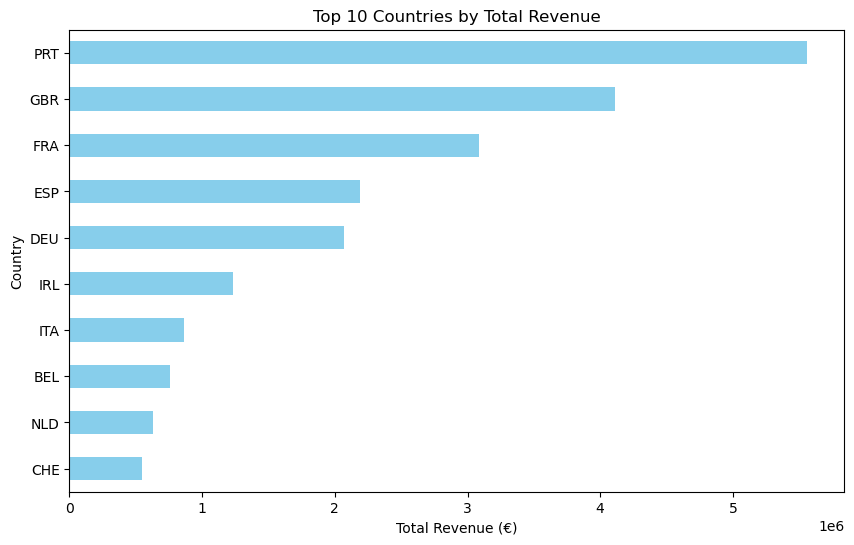

In [197]:
plt.figure(figsize=(10,6))
country_summary['revenue'].sort_values().plot(kind='barh', color='skyblue')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Total Revenue (€)')
plt.ylabel('Country')
plt.show()


In [198]:
# Monthly performance analysis
month_summary = (
    df.groupby('arrival_date_month')
      .agg({'adr':'mean',
            'revenue':'sum',
            'is_canceled':'mean',
            'lead_time':'mean'})
      .reindex([
          'January','February','March','April','May','June',
          'July','August','September','October','November','December'
      ])  # Ensures chronological order
      .round(2)
)

print(month_summary)


                       adr     revenue  is_canceled  lead_time
arrival_date_month                                            
January              72.04   792667.82         0.31      45.59
February             74.94  1162128.60         0.34      48.15
March                81.34  1677325.77         0.32      70.47
April               101.08  2109814.80         0.41      95.04
May                 109.49  2402892.45         0.40     118.24
June                117.04  2580887.32         0.42     128.55
July                125.55  4046674.50         0.38     136.71
August              135.75  4743619.28         0.38     121.49
September           105.99  2365598.62         0.39     136.70
October              89.42  1883017.61         0.38     123.54
November             75.54  1048940.82         0.32      77.21
December             82.88  1099614.33         0.35      74.25


| Observation                          | Interpretation                                                                                                                                                          |
| ------------------------------------ | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 🏖️ **Peak Season (July–August)**    | Highest ADR (€125–€136) and revenue — clear high-demand season (likely summer holidays). Both hotels can charge more, even though cancellations remain moderate (~38%). |
| 🌷 **Spring Growth (Apr–Jun)**       | ADR and revenue ramp up sharply — early summer travel and events. Lead times also increase → guests book earlier.                                                       |
| 🍂 **Autumn Decline (Sept–Oct)**     | ADR drops (to €105–€89), yet cancellations stay slightly high (~38%) — perhaps due to transitional weather or last-minute plan changes.                                 |
| ❄️ **Low Season (Jan–Mar, Nov–Dec)** | Low ADR and revenue, but shorter lead times — last-minute, low-cost bookings typical of off-season. Great time for discount campaigns or loyalty offers.                |

- Use dynamic pricing to maximize ADR in summer and stimulate demand in winter.

- Plan staff and inventory around June–August peaks.

- Lower-season months (Jan–Feb) could be ideal for local promotions or business travelers.

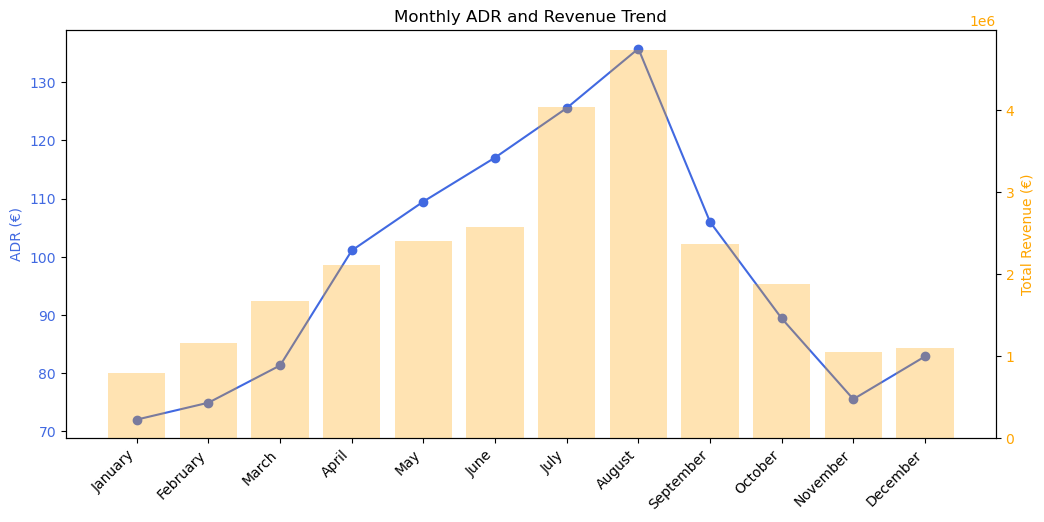

In [199]:
fig, ax1 = plt.subplots(figsize=(12,6))

# ADR (left axis)
ax1.plot(month_summary.index, month_summary['adr'], marker='o', label='ADR (€)', color='royalblue')
ax1.set_ylabel('ADR (€)', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')

# Revenue (right axis)
ax2 = ax1.twinx()
ax2.bar(month_summary.index, month_summary['revenue'], alpha=0.3, color='orange', label='Revenue (€)')
ax2.set_ylabel('Total Revenue (€)', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Monthly ADR and Revenue Trend')
fig.autofmt_xdate(rotation=45)
plt.show()


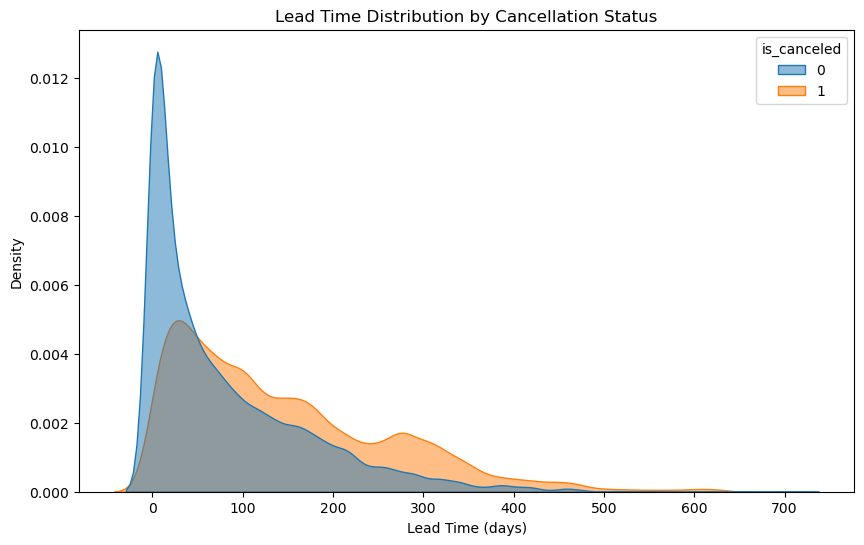

            cancel_rate      adr
lead_time                       
(0, 30]           0.210  102.796
(30, 90]          0.378  105.593
(90, 180]         0.448  108.307
(180, 365]        0.555   95.030
(365, 710]        0.677   79.188


In [200]:
# 1. Distribution of lead times by cancellation status
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='lead_time', hue='is_canceled', fill=True, common_norm=False, alpha=0.5)
plt.title('Lead Time Distribution by Cancellation Status')
plt.xlabel('Lead Time (days)')
plt.ylabel('Density')
plt.show()

# 2. Correlation between lead time and cancellation rate
lead_cancel = (
    df.groupby(pd.cut(df['lead_time'], bins=[0, 30, 90, 180, 365, 710]))
      .agg({'is_canceled': 'mean', 'adr': 'mean'})
      .rename(columns={'is_canceled': 'cancel_rate'})
)
print(lead_cancel.round(3))


| Lead Time Range (days) | Avg ADR (€) | Cancel Rate | Insights                                                                                              |
| ---------------------: | ----------: | ----------: | ----------------------------------------------------------------------------------------------------- |
|                   0–30 |   **102.8** |     **21%** | Short-term bookings → lower cancellations (guests are confident, near-date stays).                    |
|                  30–90 |   **105.6** |     **38%** | Moderate lead time → higher cancellation risk.                                                        |
|                 90–180 |   **108.3** |     **45%** | Longer planning horizon → increased uncertainty.                                                      |
|                180–365 |    **95.0** |     **55%** | Far-ahead bookings drop in price and reliability.                                                     |
|                365–710 |    **79.2** |     **68%** | Extremely early bookings → very high cancellation risk, often speculative or bulk-group reservations. |

Cancellation risk rises with longer lead times
→ Guests booking early are more likely to cancel later (perhaps due to changes in travel plans, early price hunting, or flexible policies).

ADR drops for the longest lead times
→ Hotels may offer early-bird discounts that attract less committed customers, leading to higher cancellations.

High-value zone: 0–90 days window
→ These segments combine strong ADR and low-to-moderate cancellation rates → best balance for profitability and occupancy.

- Dynamic policy strategy:

    For bookings >180 days, consider stricter or semi-flexible cancellation policies.

    Offer non-refundable incentives (e.g., small discounts) to secure commitment early.

- Pricing:

    Maintain premium pricing (ADR ~105–110) for bookings within 90 days.

    Evaluate whether long-lead discounts are truly beneficial given the 2–3× higher cancellation risk.

- Marketing:

    Segment campaigns:

    Promote flexibility for short-term guests.

    Push commitment incentives for long-term planners.

In [201]:
df['effective_adr'] = df['adr'] * (1 - df['is_canceled'])

segment_perf = df.groupby('market_segment').agg({
    'adr': 'mean',
    'effective_adr': 'mean',
    'is_canceled': 'mean',
    'lead_time': 'mean',
    'revenue': 'mean'
}).round(2)


channel_perf = df.groupby('distribution_channel').agg({
    'adr': 'mean',
    'effective_adr': 'mean',
    'is_canceled': 'mean',
    'lead_time': 'mean',
    'revenue': 'mean'
}).round(2)

display(segment_perf)
display(channel_perf)


,adr,effective_adr,is_canceled,lead_time,revenue
market_segment,,,,,
Aviation,102.74,79.67,0.22,4.54,306.79
Complementary,78.39,78.17,0.12,13.70,130.83
Corporate,70.43,55.49,0.19,22.24,113.19
Direct,114.35,95.71,0.15,50.02,320.56
Groups,80.32,30.82,0.61,187.13,97.09
Offline TA/TO,88.13,55.60,0.35,135.59,236.21
Online TA,116.23,71.61,0.37,83.31,241.35
Undefined,15.00,0.00,1.00,1.50,0.00


,adr,effective_adr,is_canceled,lead_time,revenue
distribution_channel,,,,,
Corporate,71.49,54.39,0.22,45.06,129.41
Direct,108.70,89.88,0.18,58.09,296.82
GDS,122.86,98.97,0.19,21.01,174.22
TA/TO,103.11,60.05,0.41,115.52,212.84
Undefined,46.24,22.54,0.80,23.00,112.70


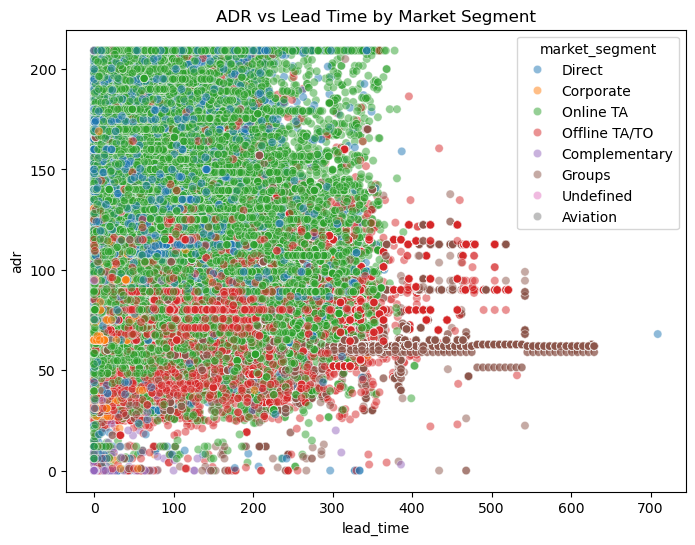

In [202]:

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='lead_time', y='adr', hue='market_segment', alpha=0.5)
plt.title("ADR vs Lead Time by Market Segment")
plt.show()


| Segment                    | Effective ADR                                                 | Cancel Rate | Lead Time                                               | Key Insight                                                           |
| -------------------------- | ------------------------------------------------------------- | ----------- | ------------------------------------------------------- | --------------------------------------------------------------------- |
| **Direct**                 | 95.71                                                         | **15%**     | Moderate (50 days)                                      | Most profitable and reliable — high ADR and low cancellations.        |
| **Online TA**              | 71.61                                                         | **37%**     | 83 days                                                 | Strong contributor but risky — cancellations erode ~38% of its value. |
| **Offline TA/TO**          | 55.60                                                         | **35%**     | 135 days                                                | Longest lead times; lower ADR → indicates group/package deals.        |
| **Groups**                 | 30.82                                                         | **61%**     | 187 days                                                | Unstable and low-yield — early bookings but high drop-off.            |
| **Corporate**              | 55.49                                                         | **19%**     | Shorter stays and lower ADR → stable business bookings. |                                                                       |
| **Complementary/Aviation** | Low cancel rates but low volumes → negligible revenue impact. |             |                                                         |                                                                       |


- The TA/TO (travel agency/tour operator) channel dominates bookings but contributes less real revenue due to cancellations.

- Direct and GDS provide better ROI and shorter booking cycles.

- Shifting marketing and pricing efforts toward those channels could yield higher profits with less volatility.

In [203]:
guest_behavior = df[['total_guests', 'total_nights', 'total_of_special_requests', 
                     'required_car_parking_spaces', 'is_repeated_guest']].describe().round(2)
display(guest_behavior)

guest_cancellation = df.groupby('is_canceled').agg({
    'total_guests': 'mean',
    'total_nights': 'mean',
    'total_of_special_requests': 'mean',
    'required_car_parking_spaces': 'mean'
}).round(2)
display(guest_cancellation)


,total_guests,total_nights,total_of_special_requests,required_car_parking_spaces,is_repeated_guest
count,118662.00,118662.00,118662.00,118662.00,118662.00
mean,1.97,3.45,0.57,0.06,0.03
std,0.65,2.55,0.79,0.25,0.17
min,1.00,1.00,0.00,0.00,0.00
25%,2.00,2.00,0.00,0.00,0.00
50%,2.00,3.00,0.00,0.00,0.00
75%,2.00,4.00,1.00,0.00,0.00
max,12.00,69.00,5.00,8.00,1.00


,total_guests,total_nights,total_of_special_requests,required_car_parking_spaces
is_canceled,,,,
0,1.95,3.42,0.72,0.1
1,2.01,3.49,0.33,0.0


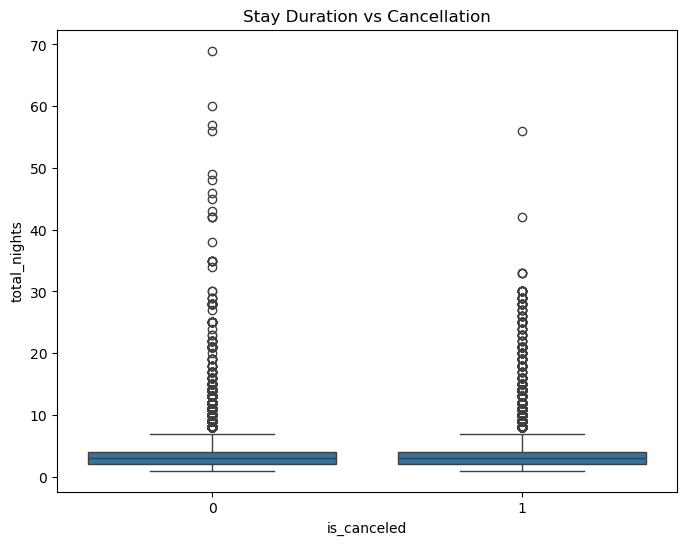

In [204]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='is_canceled', y='total_nights')
plt.title('Stay Duration vs Cancellation')
plt.show()

| Metric                           | Mean                                                                                                | Interpretation |
| -------------------------------- | --------------------------------------------------------------------------------------------------- | -------------- |
| **Guests per booking:** 1.97     | Nearly all bookings are for **1–2 people**, indicating mostly **couples or solo travelers**.        |                |
| **Nights per stay:** 3.45        | Average trip lasts **3–4 nights**, so this is not long-term accommodation.                          |                |
| **Special requests:** 0.57 (avg) | About half of guests make at least one request → opportunity for **personalized upselling**.        |                |
| **Parking spaces:** 0.06 (avg)   | Very few require parking → majority of guests are **non-drivers or tourists** relying on transfers. |                |
| **Repeated guests:** 3 %         | Extremely low **loyalty rate**, suggesting limited retention or follow-up strategies.               |                |


| Metric               | Not Canceled (0) | Canceled (1) | Insight                                                                                    |
| -------------------- | ---------------- | ------------ | ------------------------------------------------------------------------------------------ |
| **Guests**           | 1.95             | 2.01         | Cancellations slightly higher for **larger groups** → less commitment.                     |
| **Nights**           | 3.42             | 3.49         | No real difference → stay length isn’t a major driver of cancellations.                    |
| **Special Requests** | 0.72             | 0.33         | 🔑 Guests who make requests cancel **less** → they’re more invested and likely to show up. |
| **Parking Spaces**   | 0.10             | 0.00         | Those needing parking almost never cancel → local or road-trip guests = **more reliable**. |


“Engaged” guests (special requests / parking / repeat) are far less likely to cancel.

Marketing automation could encourage requests or small pre-arrival customizations to strengthen commitment.

With only 3 % repeat visitors, SmartStay should create a retention campaign (email loyalty or referral incentives).

# ✅ Summary of Key Insights So Far

| Dimension             | What We Learned                                       | Business Implication                                         |
| --------------------- | ----------------------------------------------------- | ------------------------------------------------------------ |
| **Channel & Segment** | Direct & GDS = profitable & stable; TA/TO = volatile. | Shift pricing & campaigns toward direct bookings.            |
| **Deposit & Meal**    | “No Deposit” drives most sales but adds risk.         | Stricter cancellation policy for flexible plans.             |
| **Country**           | Portugal & UK dominate but differ in reliability.     | Target stable, high-value markets (DEU, FRA).                |
| **Guest Behavior**    | Engaged guests cancel less; loyalty = low.            | Create retention, upselling, and personalization strategies. |

In [205]:
# Room Type performance summary
room_performance = df.groupby('reserved_room_type').agg({
    'adr': 'mean',
    'is_canceled': 'mean',
    'lead_time': 'mean',
    'revenue': 'mean'
}).round(2)
display(room_performance)

# Step 6.2: Compare assigned vs reserved rooms (to detect upgrades/downgrades)
room_comparison = (df['reserved_room_type'] != df['assigned_room_type']).mean()
print("Percentage of room type changes:", round(room_comparison * 100, 2), "%")


,adr,is_canceled,lead_time,revenue
reserved_room_type,,,,
A,91.94,0.39,111.44,171.52
B,92.57,0.33,113.61,194.83
C,152.49,0.33,79.69,456.05
D,120.71,0.32,87.04,314.65
E,123.17,0.29,91.45,381.64
F,162.17,0.31,68.67,382.79
G,161.61,0.37,80.73,392.04
H,167.49,0.41,78.62,347.87
L,124.67,0.33,0.00,125.67


Percentage of room type changes: 12.25 %


| Category            | Finding                            | Business Implication                                                             |
| ------------------- | ---------------------------------- | -------------------------------------------------------------------------------- |
| **Low-end (A–B)**   | Long lead time + high cancellation | Re-evaluate deposit policy or send reminder emails to reduce no-shows.           |
| **Mid-range (D–E)** | Strong revenue stability           | Ideal for bundling offers (e.g., HB meal plan).                                  |
| **High-end (F–H)**  | Top ADR but volatile cancellations | Introduce “early payment discount” or flexible rebooking instead of full cancel. |
| **Room Type Mix**   | 12.25% reassignment rate           | Review inventory accuracy and communication with guests.                         |


- ✅ High-revenue drivers: C, F, G rooms
- ⚠️ Risky performers: A, B, H rooms
- 🎯 Stable segment: D, E (balance between ADR, revenue, and reliability)

In [206]:
# Step 7.1: Correlation with cancellation
corr = df.corr(numeric_only=True)['is_canceled'].sort_values(ascending=False)
display(corr)

# Step 7.2: Compare canceled vs not canceled for key numeric features
cancel_comparison = df.groupby('is_canceled')[['lead_time', 'adr', 'total_of_special_requests', 'revenue']].mean().round(2)
display(cancel_comparison)

# Step 7.3 (optional): Visual check for lead_time vs cancellation bins
df['lead_time_bin'] = pd.cut(df['lead_time'], bins=[0,30,90,180,365,710])
cancel_rate_lead = df.groupby('lead_time_bin')['is_canceled'].mean().round(3)
display(cancel_rate_lead)

is_canceled                       1.000000
lead_time                         0.291484
previous_cancellations            0.110026
adults                            0.062021
days_in_waiting_list              0.053828
total_guests                      0.043778
adr                               0.030334
stays_in_week_nights              0.019574
arrival_date_year                 0.015733
total_nights                      0.012413
arrival_date_week_number          0.008773
children                          0.004837
stays_in_weekend_nights          -0.005608
arrival_date_day_of_month        -0.006154
babies                           -0.032614
agent                            -0.046095
previous_bookings_not_canceled   -0.057506
is_repeated_guest                -0.077596
booking_changes                  -0.144724
required_car_parking_spaces      -0.196681
total_of_special_requests        -0.235932
revenue                          -0.565733
effective_adr                    -0.818981
Name: is_ca

,lead_time,adr,total_of_special_requests,revenue
is_canceled,,,,
0,80.45,101.06,0.72,347.9
1,144.90,103.75,0.33,0.0


lead_time_bin
(0, 30]       0.210
(30, 90]      0.378
(90, 180]     0.448
(180, 365]    0.555
(365, 710]    0.677
Name: is_canceled, dtype: float64

| Variable                      | Correlation with `is_canceled` | Insight                                                                                                             |
| ----------------------------- | ------------------------------ | ------------------------------------------------------------------------------------------------------------------- |
| `effective_adr`               | **-0.82**                      | 🔥 Strongest negative correlation → lower *effective ADR* (i.e., canceled bookings = zero revenue) drives the loss. |
| `revenue`                     | **-0.57**                      | High cancellations = direct revenue loss.                                                                           |
| `total_of_special_requests`   | **-0.24**                      | Guests who make special requests are **less likely to cancel** → indicates engagement and intent to stay.           |
| `required_car_parking_spaces` | **-0.20**                      | Parking needs = more committed guests (local travelers or families).                                                |
| `lead_time`                   | **+0.29**                      | Longer lead times → higher cancellation likelihood.                                                                 |
| `booking_changes`             | **-0.14**                      | More booking changes = reduced cancellations (flexibility reduces risk).                                            |
| `is_repeated_guest`           | **-0.08**                      | Repeat guests are loyal, cancel less.                                                                               |
| `previous_cancellations`      | **+0.11**                      | Past behavior predicts future cancellations.                                                                        |

🔺 Risk Factors: Long lead time, new guests, no requests, no parking, and low engagement.

🟩 Safe Bookings: Returning guests, those with requests, parking, or short notice bookings.

| Lead Time    | Cancellation Rate |
| ------------ | ----------------- |
| 0–30 days    | 21%               |
| 31–90 days   | 38%               |
| 91–180 days  | 45%               |
| 181–365 days | 55%               |
| 366–710 days | **68%** ⚠️        |

📊 Interpretation: The earlier people book, the more likely they are to cancel — possibly due to changing plans, better deals, or long-term uncertainty.

💼 Recommendation:

Offer flexible rebooking or small non-refundable deposits for long lead-time reservations.

Encourage last-minute deals — they bring more reliable guests.

**1️⃣ Key Correlation Drivers (Numerical)**

| Variable                        | Correlation with `is_canceled` | Interpretation                                                                                                                   |
| ------------------------------- | ------------------------------ | -------------------------------------------------------------------------------------------------------------------------------- |
| **effective_adr**               | **-0.819**                     | Lower net revenue per booking = much higher cancel rate. Indicates that deeply discounted or refunded bookings are most at risk. |
| **revenue**                     | **-0.566**                     | The higher the expected revenue, the lower the chance of cancellation.                                                           |
| **total_of_special_requests**   | **-0.236**                     | Guests making special requests are less likely to cancel → higher commitment.                                                    |
| **required_car_parking_spaces** | **-0.197**                     | Indicates local/traveling guests who plan to arrive by car, hence more committed.                                                |
| **booking_changes**             | **-0.145**                     | Guests who make changes instead of canceling outright are lower-risk.                                                            |
| **is_repeated_guest**           | **-0.078**                     | Loyal guests rarely cancel.                                                                                                      |
| **lead_time**                   | **+0.291**                     | Longer booking horizons strongly correlate with cancellations.                                                                   |

___
**2️⃣ Behavioral & Categorical Drivers**

| Category                 | Risk Pattern                                                   | Insight                                                                                  |
| ------------------------ | -------------------------------------------------------------- | ---------------------------------------------------------------------------------------- |
| **Lead Time**            | 9% → 67% cancel rate increase from <7 days to >365 days        | Guests booking far ahead are the most uncertain.                                         |
| **Market Segment**       | “Groups” (58%) and “Offline TA/TO” (24%) top risk              | Bulk and agency-driven bookings carry refund flexibility and higher uncertainty.         |
| **Distribution Channel** | “TA/TO” (33%) and “Corporate” (27%) vs. “Direct” (19%)         | Direct customers are more reliable; TA/TO cancellations are more volatile.               |
| **Room Type**            | Types H & G (≈40%) vs. A & B (≈33%)                            | Premium rooms have slightly higher cancellation — likely because they’re booked earlier. |
| **Special Requests**     | Canceled bookings average only 0.33 vs. 0.72 for kept bookings | Shows strong link between engagement and commitment.                                     |

___
**3️⃣ Risk Profile Summary**

| Risk Tier            | Typical Guest Profile                                                                                  | Description                         |
| -------------------- | ------------------------------------------------------------------------------------------------------ | ----------------------------------- |
| 🔴 **High-Risk**     | Group or OTA customer, long lead time (>180 days), no special requests, no parking, non-repeated guest | Highest cancellation probability    |
| 🟡 **Moderate-Risk** | Mid-range TA/TO or Corporate booking, lead time 30–180 days, 1–2 special requests                      | Potential to retain with engagement |
| 🟢 **Low-Risk**      | Direct booking, short lead time (<30 days), repeated guest, at least 1 special request                 | Reliable / loyal segment            |
___
**4️⃣ Actionable Insights**

**Policy Adjustment:**
Implement stricter or partial prepayment for bookings with lead_time > 90 days or group segment.

**Personalization:**
Encourage special requests or booking changes instead of outright cancellations.

**Loyalty Focus:**
Reward repeat guests and direct-booking behaviors with targeted offers.

**Pricing Strategy:**
Track ADR decline in high-cancel channels — avoid excessive discounting that attracts high-risk bookings.

- **Revenue Lost Due to Cancellations**

- Code Template: Base Calculation

In [207]:
# Potential revenue (as if all bookings were realized)
df['potential_revenue'] = df['adr'] * df['total_nights']

# Realized revenue (already cleaned one, valid only for non-canceled)
df['realized_revenue'] = df['potential_revenue'].where(df['is_canceled'] == 0, 0)

# Now calculate lost revenue
total_potential = df['potential_revenue'].sum()
realized = df['realized_revenue'].sum()
lost = total_potential - realized

print(f"Total potential revenue: ${total_potential:,.2f}")
print(f"Revenue lost to cancellations: ${lost:,.2f} ({(lost / total_potential)*100:.2f}%)")
print(f"Revenue realized: ${realized:,.2f} ({(realized / total_potential)*100:.2f}%)")


Total potential revenue: $42,384,656.22
Revenue lost to cancellations: $16,471,474.30 (38.86%)
Revenue realized: $25,913,181.92 (61.14%)


- Group-Level Analysis (By Hotel Type, Market Segment, etc.)

In [208]:
rev_loss_by_hotel = (
    df.groupby('hotel')
      .agg(total_potential=('potential_revenue', 'sum'),
           realized=('realized_revenue', 'sum'))
)
rev_loss_by_hotel['lost'] = rev_loss_by_hotel['total_potential'] - rev_loss_by_hotel['realized']
rev_loss_by_hotel['loss_rate'] = rev_loss_by_hotel['lost'] / rev_loss_by_hotel['total_potential'] * 100
rev_loss_by_hotel


,total_potential,realized,lost,loss_rate
hotel,,,,
City Hotel,25318310.80,1.449038e+07,1.082793e+07,42.767196
Resort Hotel,17066345.42,1.142280e+07,5.643543e+06,33.068255


| Metric                               |                   Value |
| ------------------------------------ | ----------------------: |
| 💰 **Total potential revenue**       |          $42.38 million |
| 💸 **Revenue lost to cancellations** |          $16.47 million |
| 📉 **Loss rate**                     |              **38.86%** |
| 🏨 **City Hotel loss rate**          |              **42.77%** |
| 🌴 **Resort Hotel loss rate**        |              **33.07%** |
| 💵 **Revenue realized**              | $25.91 million (61.14%) |

- Interpretation & Insights

1. City Hotel is leaking the most revenue (≈ $10.8M, 43%)

    -This aligns with its higher cancellation frequency (shorter stays, more flexible bookings).

    -Business implication: stricter policies or deposit requirements could reduce this.

2. Resort Hotels still lose a third of potential income (≈ $5.6M, 33%)

    -Likely caused by longer lead times → higher chance of guests changing plans.

    -Consider non-refundable deposits or dynamic pricing closer to stay date.

3. Nearly 39% of potential revenue is lost overall

    -This is significant, as many hotels target <25% loss.

    -A 10% reduction in cancellations could add ~$4.2M in revenue yearly.

# Booking Behavior & Seasonality Patterns

- Stay Duration & Booking Lead Time

           lead_time   total_nights
count  118662.000000  118662.000000
mean      104.441936       3.448299
std       106.885224       2.551129
min         0.000000       1.000000
25%        18.000000       2.000000
50%        70.000000       3.000000
75%       161.000000       4.000000
max       709.000000      69.000000
              lead_time  total_nights       adr   revenue  is_canceled
lead_time      1.000000      0.152540 -0.087012 -0.043309     0.291484
total_nights   0.152540      1.000000  0.047853  0.505049     0.012413
adr           -0.087012      0.047853  1.000000  0.323171     0.030334
revenue       -0.043309      0.505049  0.323171  1.000000    -0.565733
is_canceled    0.291484      0.012413  0.030334 -0.565733     1.000000


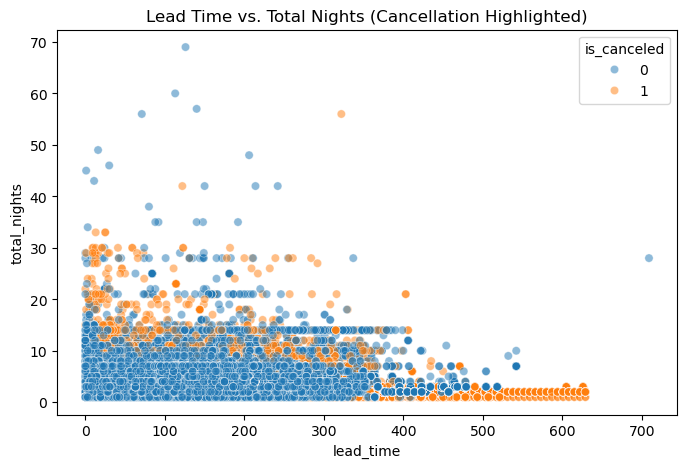

In [209]:
# Basic distributions
print(df[['lead_time', 'total_nights']].describe())

# Correlation check
print(df[['lead_time', 'total_nights', 'adr', 'revenue', 'is_canceled']].corr())

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(x='lead_time', y='total_nights', hue='is_canceled', data=df, alpha=0.5)
plt.title('Lead Time vs. Total Nights (Cancellation Highlighted)')
plt.show()


- Seasonality by Month

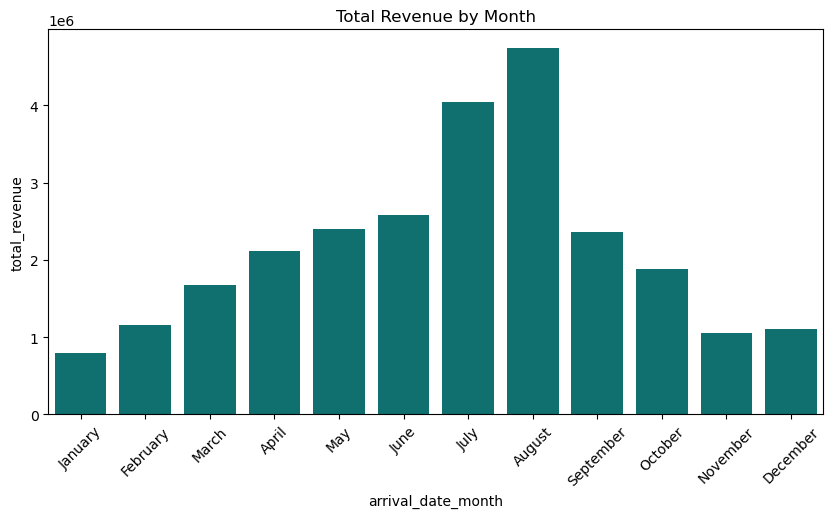

In [210]:
month_summary = df.groupby('arrival_date_month').agg(
    avg_adr=('adr', 'mean'),
    avg_lead_time=('lead_time', 'mean'),
    cancel_rate=('is_canceled', 'mean'),
    total_revenue=('revenue', 'sum')
).reset_index()

# Sort months in calendar order
month_order = ['January','February','March','April','May','June','July','August',
               'September','October','November','December']
month_summary['arrival_date_month'] = pd.Categorical(month_summary['arrival_date_month'], categories=month_order, ordered=True)
month_summary = month_summary.sort_values('arrival_date_month')

# Optional: Monthly Revenue Bar
plt.figure(figsize=(10,5))
sns.barplot(data=month_summary, x='arrival_date_month', y='total_revenue', color='teal')
plt.title('Total Revenue by Month')
plt.xticks(rotation=45)
plt.show()


- Stay Length & Revenue Contribution

In [211]:
# Group by stay length buckets
df['stay_bin'] = pd.cut(df['total_nights'], bins=[0,2,5,10,30,70], 
                        labels=['1–2','3–5','6–10','11–30','>30'])

stay_summary = df.groupby('stay_bin').agg(
    avg_adr=('adr','mean'),
    avg_lead_time=('lead_time','mean'),
    cancel_rate=('is_canceled','mean'),
    revenue=('revenue','sum')
)
stay_summary['revenue_share'] = stay_summary['revenue'] / stay_summary['revenue'].sum() * 100
stay_summary


,avg_adr,avg_lead_time,cancel_rate,revenue,revenue_share
stay_bin,,,,,
1–2,96.990724,89.173297,0.358247,4.636962e+06,17.894222
3–5,105.481751,108.246349,0.389900,1.215907e+07,46.922332
6–10,107.268288,133.697411,0.358389,7.405086e+06,28.576523
11–30,96.361599,145.789197,0.365201,1.661642e+06,6.412343
>30,58.273750,107.083333,0.208333,5.042201e+04,0.194581


| Variable                                 | Key Relationship                            | Insight                                                                                                 |
| ---------------------------------------- | ------------------------------------------- | ------------------------------------------------------------------------------------------------------- |
| `lead_time` ↗️ with `is_canceled` (0.29) | Longer lead times = more cancellations      | Guests who book early are more likely to cancel — likely due to changing plans or finding better deals. |
| `total_nights` ↗️ with `revenue` (0.51)  | Longer stays = higher total revenue         | Logical — multi-night stays directly increase revenue, despite slightly lower ADRs.                     |
| `adr` ↗️ with `revenue` (0.32)           | ADR drives revenue, but only moderately     | Indicates that occupancy and stay length matter more than room rate alone.                              |
| `is_canceled` ↘️ with `revenue` (-0.57)  | Cancellations have a strong negative effect | Clear revenue leakage due to canceled bookings.                                                         |

- The primary cancellation risk indicator remains lead time, while total nights and ADR are more related to profitability

| Stay Range       | ADR    | Lead Time | Cancel Rate | Revenue Share | Takeaway                                                             |
| ---------------- | ------ | --------- | ----------- | ------------- | -------------------------------------------------------------------- |
| **1–2 nights**   | 96.99  | 89.17     | 35.8%       | 17.9%         | Short stays = quick turnover, decent ADR, but notable cancellations. |
| **3–5 nights**   | 105.48 | 108.25    | **38.9%**   | **46.9%**     | Core segment – drives nearly half of total revenue.                  |
| **6–10 nights**  | 107.27 | 133.69    | 35.8%       | 28.6%         | Longer stays = high value, slightly better ADR.                      |
| **11–30 nights** | 96.36  | 145.79    | 36.5%       | 6.4%          | Extended stays are rare but steady; guests book very early.          |
| **>30 nights**   | 58.27  | 107.08    | 20.8%       | 0.19%         | Outliers; possible corporate or maintenance stays.                   |

**Key Behavioral Trends:**

Guests staying 3–5 nights generate half of all revenue — your main profit segment.

Longer stays (6–10 nights) are second most important, offering balance between lead time and cancellation risk.

Very short or very long stays contribute less revenue but show different risk profiles.

**Strategic Takeaways**

- High-value segment:
    Focus marketing on guests booking 3–10 nights — they deliver 75%+ of revenue.
    Incentivize rebooking or loyalty programs around this stay duration.

- Cancellation management:
    Since cancellations increase with longer lead times, implement:

        Reminder emails or flexible modification policies before cancellation deadlines.

        Non-refundable early-bird deals to reduce risk.

- Revenue optimization:

    Use dynamic pricing (slightly higher ADR) during months or stay ranges with stable low cancellations.

    Monitor ADR stability across 3–10 night range — it’s where most profit resides.

**Customer Segmentation & Revenue Drivers**

**Customer Type Performance**

| Customer Type       | ADR    | Revenue | Cancel Rate | Revenue Share | Key Insight                                                 |
| ------------------- | ------ | ------- | ----------- | ------------- | ----------------------------------------------------------- |
| **Transient**       | 106.99 | 215.38  | 0.41        | 🟩 **75%**    | The hotel’s lifeblood: high ADR but high cancellation risk. |
| **Transient-Party** | 87.18  | 204.81  | 0.26        | 🟨 21%        | Families/groups—lower cancellations, solid revenue.         |
| **Contract**        | 88.01  | 366.55  | 0.31        | 🟦 3%         | Long-term deals or corporate stays—steady but small volume. |
| **Group**           | 86.89  | 227.82  | 0.08        | 🟦 <1%        | Low cancellations, low frequency, possibly event-related.   |

-Transient guests dominate bookings and revenue but cancel frequently — suggesting a need for loyalty or early-payment incentives.

-Group and Contract bookings are reliable but underrepresented — potential to grow via B2B partnerships.

**Country Contribution**

| Country                 | ADR   | Revenue ($) | Cancel Rate | Lead Time | Revenue Share | Takeaway                                                 |
| ----------------------- | ----- | ----------- | ----------- | --------- | ------------- | -------------------------------------------------------- |
| 🇵🇹 **Portugal (PRT)** | 93.5  | 5.56M       | 0.57        | 116       | 40.4%         | Biggest domestic market but *highest cancellation rate*. |
| 🇬🇧 **UK (GBR)**       | 95.8  | 4.11M       | 0.20        | 128       | 10.2%         | Reliable and long-lead bookings — valuable segment.      |
| 🇫🇷 **France (FRA)**   | 109.1 | 3.09M       | 0.19        | 82        | 8.8%          | Profitable and steady ADR; good mix of lead time.        |
| 🇪🇸 **Spain (ESP)**    | 114.7 | 2.19M       | 0.25        | 55        | 7.2%          | Regional market, moderate cancellations.                 |
| 🇩🇪 **Germany (DEU)**  | 104.6 | 2.07M       | 0.17        | 137       | 6.1%          | Early planners, low cancellations, profitable mix.       |

- The domestic market (Portugal) dominates bookings but is risky (high cancellations).

- European inbound guests (UK, FR, DE) are higher-value & more stable — focus for retention and premium offers.

**Market Segment & Distribution Channel Drivers**

- Market Segment Drivers:

Online TA — 47% of bookings, high cancellation (37%), but top reach.

Offline TA/TO — 20%, lower ADR but steady performance.

Direct bookings — 10%, highest revenue efficiency (low cancellations, high ADR).

- Distribution Channels:

TA/TO (Travel Agents/Tour Operators) dominate volume but suffer 41% cancellations.

Direct & GDS channels yield best ADR and retention — ideal for upselling and loyalty programs.

- 📈 Recommendation:

“Invest in optimizing Direct and Corporate channels — even small growth here significantly boosts stable revenue.”

**Guest & Stay Behavior Summary**

| Feature          | Trend                                 | Impact                                                               |
| ---------------- | ------------------------------------- | -------------------------------------------------------------------- |
| Total Guests     | Mean = 1.97                           | Mostly couples or solo travelers — 2-person stays dominate.          |
| Total Nights     | Mean = 3.45                           | Short to medium stays dominate; 3–5 night bookings = 47% of revenue. |
| Special Requests | Higher requests → Lower cancellations | Suggests more serious, committed guests.                             |
| Repeated Guests  | Only 3%                               | Opportunity for loyalty program expansion.                           |


**Key Revenue Drivers (Ranked)**
| Rank                 | Driver                                    | Effect on Revenue |
| -------------------- | ----------------------------------------- | ----------------- |
| 🥇 `total_nights`    | Direct multiplier effect                  |                   |
| 🥈 `adr`             | Influences margin and revenue             |                   |
| 🥉 `is_canceled`     | Negative impact                           |                   |
| 4️⃣ `market_segment` | Defines volume source                     |                   |
| 5️⃣ `lead_time`      | Indirectly affects cancellation and yield |                   |


**Summary — Customer Segmentation & Drivers**


-Most revenue comes from Transient guests via Online TA, but this group has high cancellations.

-Direct and corporate guests provide steady revenue and lower risk.

-The Portuguese domestic market is large but unstable — target re-engagement campaigns here.

-3–5 night stays remain the sweet spot for optimizing revenue yield.

In [212]:
# assume df has columns: 'potential_revenue' (adr * total_nights), 'is_canceled', 'market_segment', 'distribution_channel', 'hotel', 'arrival_date_month'

total_potential = df['potential_revenue'].sum()
total_lost = (df['potential_revenue'] * (df['is_canceled']==1)).sum()
realized = total_potential - total_lost

def scenario_relative_reduction(percent=0.10):
    saved = total_lost * percent
    new_lost = total_lost - saved
    new_realized = realized + saved
    return {'saved': saved, 'new_lost': new_lost, 'new_realized': new_realized}

def scenario_absolute_loss_rate(new_loss_rate):
    # new_loss_rate as decimal, e.g., 0.2886 for 28.86%
    new_lost = total_potential * new_loss_rate
    new_realized = total_potential - new_lost
    return {'new_loss_rate': new_loss_rate, 'new_lost': new_lost, 'new_realized': new_realized}

# Example: relative 10%
print(scenario_relative_reduction(0.10))

# Example: absolute 10 percentage points reduction
current_loss_rate = total_lost / total_potential
target_loss_rate = current_loss_rate - 0.10
print(scenario_absolute_loss_rate(target_loss_rate))

# ---------- segmented scenario (target only a channel)
def channel_targeted_savings(channel_name, percent_reduction=0.1):
    mask = df['distribution_channel'] == channel_name
    potential_ch = df.loc[mask, 'potential_revenue'].sum()
    lost_ch = df.loc[mask & (df['is_canceled']==1), 'potential_revenue'].sum()
    saved = lost_ch * percent_reduction
    return {'channel': channel_name, 'lost_ch': lost_ch, 'saved': saved, 'new_realized_total': realized + saved}

# Example: save 10% lost revenue for TA/TO
print(channel_targeted_savings('TA/TO', 0.10))


{'saved': np.float64(1647147.43), 'new_lost': np.float64(14824326.87), 'new_realized': np.float64(27560329.35)}
{'new_loss_rate': np.float64(0.2886188014479547), 'new_lost': np.float64(12233008.677999998), 'new_realized': np.float64(30151647.542000003)}
{'channel': 'TA/TO', 'lost_ch': np.float64(15069813.8), 'saved': np.float64(1506981.3800000001), 'new_realized_total': np.float64(27420163.3)}


In [217]:
# app.py
import pandas as pd
import numpy as np
import calendar

import dash
from dash import dcc, html, dash_table, Input, Output, State
import plotly.express as px
import plotly.graph_objects as go

# ---------- CONFIG ----------
DATA_PATH = "D:\programing\DEPI python\SmartStay Python\smart_stay_cleaned.csv"  # update if different
MONTH_ORDER = ['January','February','March','April','May','June','July','August','September','October','November','December']

# ---------- LOAD & PREP DATA ----------
df = pd.read_csv(DATA_PATH)

# Ensure key columns exist and types
for col in ['is_canceled','adr','total_nights']:
    if col not in df.columns:
        raise ValueError(f"Required column missing: {col}")

# Create potential_revenue and realized (if not already present)
if 'potential_revenue' not in df.columns:
    df['potential_revenue'] = df['adr'] * df['total_nights']

# realized_revenue: revenue if booking completed, else 0
# Some datasets may have 'revenue' already as realized revenue; we accept it if present
if 'revenue' in df.columns:
    df['realized_revenue'] = df['revenue'].fillna(0)
else:
    df['realized_revenue'] = np.where(df['is_canceled'] == 0, df['potential_revenue'], 0)

# Safety: real realized might also be potential for non-canceled if revenue missing
df['realized_revenue'] = np.where((df['is_canceled'] == 0) & (df['realized_revenue'] == 0), df['potential_revenue'], df['realized_revenue'])

# Lead time bins and stay bins
df['lead_time_bin'] = pd.cut(df['lead_time'], bins=[-1,30,90,180,365,10000],
                             labels=['0-30','31-90','91-180','181-365','366+'])
df['stay_bin'] = pd.cut(df['total_nights'], bins=[0,2,5,10,30,1000],
                        labels=['1–2','3–5','6–10','11–30','>30'])

# Arrival month ordering
if 'arrival_date_month' in df.columns:
    df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=MONTH_ORDER, ordered=True)

# Small cleaning for missing categorical values
cat_cols = ['hotel','market_segment','distribution_channel','country']
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].fillna('Undefined').astype(str)

# Base totals (used as baseline)
BASE_TOTAL_POTENTIAL = df['potential_revenue'].sum()
BASE_TOTAL_LOST = df.loc[df['is_canceled'] == 1, 'potential_revenue'].sum()
BASE_REALIZED = BASE_TOTAL_POTENTIAL - BASE_TOTAL_LOST
BASE_CANCEL_RATE = df['is_canceled'].mean()

# ---------- DASH APP ----------
app = dash.Dash(__name__, suppress_callback_exceptions=True)
app.title = "Smart Stay Revenue & Cancellation Dashboard"

# ---------- LAYOUT ----------
app.layout = html.Div([
    html.H1("Smart Stay — Revenue & Cancellation Insights", style={'textAlign':'center'}),
    html.Div([
        # Filters column
        html.Div([
            html.H4("Filters"),
            html.Label("Hotel"),
            dcc.Dropdown(options=[{'label':h,'value':h} for h in df['hotel'].unique()],
                         value=None, multi=False, placeholder="All hotels", id='filter_hotel'),
            html.Br(),
            html.Label("Market Segment"),
            dcc.Dropdown(options=[{'label':s,'value':s} for s in sorted(df['market_segment'].unique())],
                         value=[], multi=True, placeholder="All segments", id='filter_segment'),
            html.Br(),
            html.Label("Distribution Channel"),
            dcc.Dropdown(options=[{'label':c,'value':c} for c in sorted(df['distribution_channel'].unique())],
                         value=[], multi=True, placeholder="All channels", id='filter_channel'),
            html.Br(),
            html.Label("Country (top 10 quick select)"),
            dcc.Dropdown(options=[{'label':c,'value':c} for c in df['country'].value_counts().nlargest(10).index],
                         value=[], multi=True, placeholder="All countries", id='filter_country'),
            html.Br(),
            html.Label("Months"),
            dcc.Dropdown(options=[{'label':m,'value':m} for m in MONTH_ORDER],
                         value=[], multi=True, placeholder="All months", id='filter_months'),
            html.Hr(),
            html.H4("Simulations"),
            html.Label("Overall Cancel Reduction (%)"),
            dcc.Slider(id='sim_reduction_pct', min=0, max=50, step=1, value=0,
                       marks={i:f"{i}%" for i in range(0,51,10)}),
            html.Br(),
            html.Label("Channel-targeted Save (%)"),
            dcc.Dropdown(options=[{'label':c,'value':c} for c in df['distribution_channel'].unique()],
                         value='TA/TO', id='sim_channel'),
            dcc.Slider(id='sim_channel_pct', min=0, max=50, step=1, value=0,
                       marks={i:f"{i}%" for i in range(0,51,10)}),
            html.Br(),
            html.Label("Shift OTA → Direct (%)"),
            dcc.Slider(id='sim_shift_ota_to_direct', min=0, max=30, step=1, value=0,
                       marks={i:f"{i}%" for i in range(0,31,5)}),
            html.Br(),
            html.Button("Apply / Update", id='apply_btn', n_clicks=0, style={'width':'100%'}),
            html.Br(), html.Br(),
            html.Div("Tip: try reducing TA/TO losses or shifting OTA bookings to Direct to see impact.", style={'fontStyle':'italic'})
        ], style={'width':'22%','display':'inline-block','verticalAlign':'top','padding':'10px','boxShadow':'0 0 6px rgba(0,0,0,0.08)','backgroundColor':'#fff','borderRadius':'6px'}),
        # Main content column
        html.Div([
            # KPI Cards
            html.Div(id='kpi_container', style={'display':'flex','justifyContent':'space-between','gap':'12px'}),
            html.Br(),
            # Row: Funnel + Monthly trend
            html.Div([
                html.Div(dcc.Graph(id='funnel_chart'), style={'width':'48%', 'display':'inline-block'}),
                html.Div(dcc.Graph(id='monthly_trend'), style={'width':'50%', 'display':'inline-block','verticalAlign':'top'})
            ]),
            # Row: Segment & Channel cancellation
            html.Div([
                html.Div(dcc.Graph(id='cancel_by_segment'), style={'width':'48%','display':'inline-block'}),
                html.Div(dcc.Graph(id='heatmap_month_channel'), style={'width':'50%','display':'inline-block','verticalAlign':'top'})
            ]),
            # Row: Revenue by hotel + stay_bin share
            html.Div([
                html.Div(dcc.Graph(id='revenue_by_hotel'), style={'width':'48%','display':'inline-block'}),
                html.Div(dcc.Graph(id='stay_share'), style={'width':'50%','display':'inline-block','verticalAlign':'top'})
            ]),
            # Row: Scatter ADR vs Lead time + Room performance table
            html.Div([
                html.Div(dcc.Graph(id='adr_lead_scatter'), style={'width':'60%','display':'inline-block'}),
                html.Div([
                    html.H5("Room Type Performance"),
                    dash_table.DataTable(id='room_table',
                                         columns=[{"name":"room","id":"room"},{"name":"avg_adr","id":"avg_adr"},{"name":"cancel_rate","id":"cancel_rate"},{"name":"avg_lead_time","id":"avg_lead_time"},{"name":"revenue","id":"revenue"}],
                                         data=[], page_size=8,
                                         style_table={'overflowX':'auto'},
                                         style_cell={'textAlign':'left'}),
                ], style={'width':'38%','display':'inline-block','paddingLeft':'12px','verticalAlign':'top'})
            ]),
            html.Br(),
            # Footer / Export
            html.Div([
                html.Button("Export Scenario CSV", id='export_btn'),
                html.Div(id='export_status', style={'display':'inline-block','paddingLeft':'12px'})
            ])
        ], style={'width':'75%','display':'inline-block','paddingLeft':'20px','verticalAlign':'top'})
    ], style={'width':'100%','display':'flex','gap':'20px'})
], style={'fontFamily':'Segoe UI, Roboto, Arial','padding':'12px','backgroundColor':'#f7f9fc'})

# ---------- CALLBACK HELPERS ----------
def filter_df(hotel, segments, channels, countries, months):
    d = df.copy()
    if hotel:
        d = d[d['hotel'] == hotel]
    if segments and len(segments) > 0:
        d = d[d['market_segment'].isin(segments)]
    if channels and len(channels) > 0:
        d = d[d['distribution_channel'].isin(channels)]
    if countries and len(countries) > 0:
        d = d[d['country'].isin(countries)]
    if months and len(months) > 0 and 'arrival_date_month' in d.columns:
        d = d[d['arrival_date_month'].isin(months)]
    return d

def apply_simulation(dff, reduction_pct=0.0, channel=None, channel_pct=0.0, shift_ota_pct=0.0):
    """
    dff: filtered df copy
    reduction_pct: overall relative reduction in lost revenue (0-1)
    channel: distribution channel to target for additional reduction
    channel_pct: percent reduction for that channel (0-1)
    shift_ota_pct: percent of OTA bookings to shift to Direct (0-1) - moves potential & realized volumes
    Returns: dict of computed totals and modified DataFrame used for plotting
    """
    df_sim = dff.copy()

    # initial potentials and lost in filtered view
    total_potential = df_sim['potential_revenue'].sum()
    lost_mask = df_sim['is_canceled'] == 1
    total_lost = df_sim.loc[lost_mask, 'potential_revenue'].sum()
    realized = total_potential - total_lost

    # 1) overall reduction applied to lost bookings proportionally
    saved_overall = total_lost * reduction_pct
    total_lost_after = total_lost - saved_overall

    # 2) targeted channel reduction
    saved_channel = 0
    if channel and channel in df_sim['distribution_channel'].unique():
        mask_ch = (df_sim['distribution_channel'] == channel) & (df_sim['is_canceled'] == 1)
        lost_channel = df_sim.loc[mask_ch, 'potential_revenue'].sum()
        saved_channel = lost_channel * channel_pct
        total_lost_after -= saved_channel

    # 3) shift OTA->Direct: move some non-canceled OTA bookings (potential & realized) to Direct
    shift_saved = 0
    if shift_ota_pct > 0:
        ota_mask = df_sim['distribution_channel'] == 'TA/TO'
        ota_count = ota_mask.sum()
        # shift proportion of rows (only for non-canceled for simplicity) from TA/TO to Direct
        ota_non_cancel_idx = df_sim.loc[ota_mask & (df_sim['is_canceled'] == 0)].index
        n_shift = int(len(ota_non_cancel_idx) * shift_ota_pct)
        if n_shift > 0:
            idx_to_shift = ota_non_cancel_idx[:n_shift]
            df_sim.loc[idx_to_shift, 'distribution_channel'] = 'Direct'
            # shifting may reduce loss if Direct has lower cancel tendency historically,
            # but here we just move the realized potential; for conservative estimate, don't claim extra saved
            shift_saved = 0

    new_realized = total_potential - total_lost_after

    return {
        'df_sim': df_sim,
        'total_potential': total_potential,
        'total_lost_before': total_lost,
        'total_lost_after': total_lost_after,
        'new_realized': new_realized,
        'saved_overall': saved_overall,
        'saved_channel': saved_channel,
        'shift_saved': shift_saved
    }

# ---------- CALLBACKS ----------
@app.callback(
    Output('kpi_container','children'),
    Output('funnel_chart','figure'),
    Output('monthly_trend','figure'),
    Output('cancel_by_segment','figure'),
    Output('heatmap_month_channel','figure'),
    Output('revenue_by_hotel','figure'),
    Output('stay_share','figure'),
    Output('adr_lead_scatter','figure'),
    Output('room_table','data'),
    Input('apply_btn','n_clicks'),
    State('filter_hotel','value'),
    State('filter_segment','value'),
    State('filter_channel','value'),
    State('filter_country','value'),
    State('filter_months','value'),
    State('sim_reduction_pct','value'),
    State('sim_channel','value'),
    State('sim_channel_pct','value'),
    State('sim_shift_ota_to_direct','value')
)
def update_all(n_clicks, hotel, segments, channels, countries, months, sim_reduction_pct, sim_channel, sim_channel_pct, sim_shift_pct):
    # Filters
    dff = filter_df(hotel, segments, channels, countries, months)

    # Convert percents
    sim_reduction = sim_reduction_pct / 100.0
    sim_channel_p = sim_channel_pct / 100.0
    sim_shift = sim_shift_pct / 100.0

    # Apply simulation
    sim_results = apply_simulation(dff, reduction_pct=sim_reduction, channel=sim_channel, channel_pct=sim_channel_p, shift_ota_pct=sim_shift)
    df_sim = sim_results['df_sim']

    total_potential = sim_results['total_potential']
    lost_before = sim_results['total_lost_before']
    lost_after = sim_results['total_lost_after']
    new_realized = sim_results['new_realized']
    saved = (sim_results['saved_overall'] + sim_results['saved_channel'] + sim_results['shift_saved'])

    # KPI cards
    kpis = []
    def card(title, value, subtitle=""):
        return html.Div([html.H4(title, style={'marginBottom':'6px'}), html.H3(value), html.Div(subtitle, style={'opacity':0.7,'fontSize':'13px'})],
                        className='card', style={'backgroundColor':'#fff','padding':'12px','borderRadius':'8px','textAlign':'center','boxShadow':'0 2px 6px rgba(0,0,0,0.07)','width':'24%'})
    loss_pct_before = (lost_before / total_potential * 100) if total_potential>0 else 0
    loss_pct_after = (lost_after / total_potential * 100) if total_potential>0 else 0
    cancel_rate = df_sim['is_canceled'].mean() * 100 if len(df_sim)>0 else 0

    kpis.append(card("Total Potential Revenue", f"${total_potential:,.0f}"))
    kpis.append(card("Revenue Realized (sim)", f"${new_realized:,.0f}", f"Saved: ${saved:,.0f}"))
    kpis.append(card("Revenue Lost (%)", f"${lost_after:,.0f}", f"{loss_pct_after:.2f}% (was {loss_pct_before:.2f}%)"))
    kpis.append(card("Cancellation Rate", f"{cancel_rate:.2f}%", "Filtered view"))

    # Funnel chart
    funnel_fig = go.Figure(go.Funnel(
        y=["Potential Revenue","Lost Revenue (after sim)","Realized Revenue (after sim)"],
        x=[total_potential, lost_after, new_realized],
        textinfo="value+percent initial"
    ))
    funnel_fig.update_layout(margin=dict(l=20,r=20,t=30,b=20))

    # Monthly trend
    if 'arrival_date_month' in df_sim.columns:
        month_df = df_sim.groupby('arrival_date_month', observed=True).agg(
            potential_revenue=('potential_revenue','sum'),
            realized_revenue=('realized_revenue','sum'),
            lost_revenue=('potential_revenue', lambda s: s[df_sim.loc[s.index,'is_canceled']==1].sum())
        ).reindex(MONTH_ORDER).reset_index()
        month_df = month_df.fillna(0)
        mt_fig = go.Figure()
        mt_fig.add_trace(go.Scatter(x=month_df['arrival_date_month'], y=month_df['potential_revenue'], name='Potential Revenue', mode='lines+markers'))
        mt_fig.add_trace(go.Scatter(x=month_df['arrival_date_month'], y=month_df['realized_revenue'], name='Realized Revenue', mode='lines+markers'))
        mt_fig.update_layout(xaxis_tickangle=-45, margin=dict(l=20,r=20,t=30,b=20))
    else:
        mt_fig = go.Figure()

    # Cancellation by market segment
    seg = df_sim.groupby('market_segment', observed=True).agg(cancel_rate=('is_canceled','mean')).sort_values('cancel_rate', ascending=False).reset_index()
    seg['cancel_pct'] = seg['cancel_rate'] * 100
    seg_fig = px.bar(seg, x='market_segment', y='cancel_pct', text='cancel_pct', labels={'cancel_pct':'Cancel Rate (%)','market_segment':'Market Segment'})
    seg_fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
    seg_fig.update_layout(margin=dict(l=20,r=20,t=30,b=20), yaxis=dict(range=[0, max(0.1, seg['cancel_pct'].max()*1.2)]))

    # Heatmap month x channel cancellation rates
    if 'arrival_date_month' in df_sim.columns:
        heat = df_sim.groupby(['arrival_date_month','distribution_channel'], observed=True).agg(cancel_rate=('is_canceled','mean')).reset_index()
        heat['arrival_date_month'] = pd.Categorical(heat['arrival_date_month'], categories=MONTH_ORDER, ordered=True)
        pivot = heat.pivot(index='arrival_date_month', columns='distribution_channel', values='cancel_rate').reindex(MONTH_ORDER)
        hm_fig = px.imshow((pivot*100).fillna(0), labels=dict(x="Channel", y="Month", color="Cancel Rate (%)"), x=pivot.columns, y=pivot.index)
        hm_fig.update_layout(margin=dict(l=60,r=20,t=30,b=30))
    else:
        hm_fig = go.Figure()

    # Revenue by hotel
    rev_h = df_sim.groupby('hotel', observed=True).agg(potential=('potential_revenue','sum'), realized=('realized_revenue','sum')).reset_index()
    rev_fig = px.bar(rev_h.melt(id_vars='hotel', var_name='Type', value_name='Revenue'), x='hotel', y='Revenue', color='Type', barmode='group', text_auto='.2s')
    rev_fig.update_layout(margin=dict(l=20,r=20,t=30,b=20))

    # Stay share
    stay = df_sim.groupby('stay_bin', observed=True).agg(revenue=('potential_revenue','sum')).reset_index()
    
    stay['revenue'] = stay['revenue'].fillna(0) # Only fill NaN in the 'revenue' column
    if stay['revenue'].sum() > 0:
        stay['share_pct'] = stay['revenue'] / stay['revenue'].sum() * 100
    stay_fig = px.pie(stay, names='stay_bin', values='share_pct', title='Revenue Share by Stay Length')

    # ADR vs Lead Time scatter
    sample = df_sim.sample(min(len(df_sim), 8000), random_state=1)
    sc_fig = px.scatter(sample, x='lead_time', y='adr', color=sample['is_canceled'].astype(str),
                        labels={'is_canceled':'Canceled'}, opacity=0.6, title='Lead Time vs ADR (color = canceled)')
    sc_fig.update_layout(margin=dict(l=20,r=20,t=30,b=20))

    # Room table
    if 'reserved_room_type' in df_sim.columns:
        room_perf = df_sim.groupby('reserved_room_type', observed=True).agg(
            avg_adr=('adr','mean'),
            cancel_rate=('is_canceled','mean'),
            avg_lead_time=('lead_time','mean'),
            revenue=('potential_revenue','sum')
        ).reset_index().rename(columns={'reserved_room_type':'room'})
        room_perf['avg_adr'] = room_perf['avg_adr'].round(2)
        room_perf['cancel_rate'] = (room_perf['cancel_rate']*100).round(2)
        room_perf['avg_lead_time'] = room_perf['avg_lead_time'].round(1)
        room_perf['revenue'] = room_perf['revenue'].round(0)
        room_data = room_perf.to_dict('records')
    else:
        room_data = []

    return kpis, funnel_fig, mt_fig, seg_fig, hm_fig, rev_fig, stay_fig, sc_fig, room_data

# Export scenario CSV (simple grouped summary)
@app.callback(
    Output('export_status','children'),
    Input('export_btn','n_clicks'),
    State('filter_hotel','value'),
    State('filter_segment','value'),
    State('filter_channel','value'),
    State('filter_country','value'),
    State('filter_months','value')
)
def export_csv(n_clicks, hotel, segments, channels, countries, months):
    if n_clicks is None or n_clicks == 0:
        return ""
    dff = filter_df(hotel, segments, channels, countries, months)
    scenario_table = dff.groupby(['hotel','market_segment','distribution_channel','arrival_date_month'], observed=True).agg(
        potential_revenue=('potential_revenue','sum'),
        canceled_potential=('potential_revenue', lambda s: s[dff.loc[s.index,'is_canceled']==1].sum()),
        realized=('realized_revenue','sum')
    ).reset_index()
    fname = "scenario_table_by_segment.csv"
    scenario_table.to_csv(fname, index=False)
    return html.Div([f"Saved: {fname}"], style={'color':'green'})

# ---------- MAIN ----------
if __name__ == '__main__':
    print("Running SmartStay Dashboard on http://127.0.0.1:8050/")
    app.run_server(debug=True)


Running SmartStay Dashboard on http://127.0.0.1:8050/
